In [1]:
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
import pickle
import math
import scipy
from pathlib import Path
import sys
import os
import warnings
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm
from matplotlib.ticker import ScalarFormatter
from copy import deepcopy
sys.path.append("../src")
from custom_distance import KL, conditionKL
import itertools
import pickle

import plotly.express as px

import plotly.io as pio
pio.renderers.default = 'iframe' # or 'notebook' or 'colab' or 'jupyterlab' iframe

from plotly.express.colors import sample_colorscale

import plotly.graph_objects as go


warnings.filterwarnings("ignore")


def get_regression(x, y):
    x = sm.add_constant(x)
    
    lr_fit = sm.OLS(y, x)
    results = lr_fit.fit()

    return results.params[-1], results


def get_coefLog10(x, y):
    x = np.log10(x)
    x = sm.add_constant(x)
    
    lr_fit = sm.OLS(y, x)
    results = lr_fit.fit()

    return results.params[-1], results


# Load Dataset

In [2]:
## alpha_train = 5 vs 0.2

dataset_name = "CD"
# dataset_name = "HateSpeech"
# dataset_name = "SHAC"



file_aug = f"../output/regression_Augmentation_{dataset_name}_BalanceAlpha/UnconstraintCy_mixup_4.0-AugUP-Sentence-BERT-ntest_200-l2-C1-V10.pkl"
file_noaug = f"../output/regression_{dataset_name}_BalanceAlpha/Sentence-BERT-ntest_200-l2-C1-V10.pkl"
file_resample = f"../output/regression_ReSample_{dataset_name}_BalanceAlpha/UnconstraintCy-AugUP-ReSample-Sentence-BERT-ntest_200-l2-C1-V10.pkl"



# file_aug_reverseTranslate = f"../output/regression_AugUp_ReverseTranslate_{dataset_name}_BalanceAlpha/UnconstraintCy-AugUP-ReSample-Sentence-BERT-ntest_200-l2-C1-V10.pkl"


In [19]:
## alpha_train = 1.5 vs 0.6667


# dataset_name = "CD"
# dataset_name = "HateSpeech"
dataset_name = "SHAC"

_alpha_train = 10

file_aug = f"../output/regression_Augmentation_{dataset_name}_BalanceAlpha/UnconstraintCy-mixup_4.0-AugUP-Sentence-BERT-ntest_200-l2-C1-V10_AlphaTrain_{_alpha_train}-Cz_0.5.pkl"
file_noaug = f"..//output/regression_Augmentation_{dataset_name}_BalanceAlpha/UnconstraintCy-noaug-AugUP-Sentence-BERT-ntest_200-l2-C1-V10_AlphaTrain_{_alpha_train}-Cz_0.5.pkl"
file_resample = f"../output/regression_Augmentation_{dataset_name}_BalanceAlpha/UnconstraintCy-ReSample-AugUP-Sentence-BERT-ntest_200-l2-C1-V10_AlphaTrain_{_alpha_train}-Cz_0.5.pkl"

# file_aug_reverseTranslate = f"../output/regression_AugUp_ReverseTranslate_{dataset_name}_BalanceAlpha/UnconstraintCy-AugUP-ReSample-Sentence-BERT-ntest_200-l2-C1-V10_AlphaTrain_{_alpha_train}-Cz_0.5.pkl"


In [ ]:
df_ls = []


with open(file_aug, "rb") as f:
    df_tmp = pickle.load(file=f)
    df_tmp['dataset'] = dataset_name
    df_tmp['set'] = "mixup_AugUp"
    df_ls.append(df_tmp)

with open(file_resample, "rb") as f:
    df_tmp = pickle.load(file=f)
    df_tmp['dataset'] = dataset_name
    df_tmp['set'] = "resample_AugUp"
    df_ls.append(df_tmp)
    
with open(file_noaug, "rb") as f:
    df_tmp = pickle.load(file=f)
    df_tmp['dataset'] = dataset_name
    df_tmp['set'] = "noAug"
    df_ls.append(df_tmp)
    
# with open(file_aug_reverseTranslate, "rb") as f:
#     df_tmp = pickle.load(file=f)
#     df_tmp['dataset'] = dataset_name
#     df_tmp['set'] = "reverseTranslate_AugUp"
#     df_ls.append(df_tmp)
        
df_eval = pd.concat(df_ls).reset_index(drop=True)    


In [22]:
## DistMatch, Sentence-BERT and binary unigram
## with Fixed Training set


# transform_method = "Sentence-BERT"
transform_method = "binaryUnigram"


# # dataset_name = "CD"
# dataset_name = "HateSpeech"
# CombinationIdx_ls = [6621, 3636, 566]


dataset_name = "SHAC"
CombinationIdx_ls = [11063, 6114, 1152]

_alpha_train_ls = [0.2, 1, 5]



df_ls = []

for _alpha_train, CombinationIdx in zip(_alpha_train_ls, CombinationIdx_ls):


    file_aug = f"../output/regression_Augmentation_{dataset_name}_BalanceAlpha/set-{CombinationIdx}/UnconstraintCy-mixup_4.0-AugUP-{transform_method}-ntest_200-l2-C1-V10_AlphaTrain_5-Cz_0.5.pkl"
    file_noaug = f"..//output/regression_Augmentation_{dataset_name}_BalanceAlpha/set-{CombinationIdx}/UnconstraintCy-noaug-AugUP-{transform_method}-ntest_200-l2-C1-V10_AlphaTrain_5-Cz_0.5.pkl"
    file_resample = f"../output/regression_Augmentation_{dataset_name}_BalanceAlpha/set-{CombinationIdx}/UnconstraintCy-ReSample-AugUP-{transform_method}-ntest_200-l2-C1-V10_AlphaTrain_5-Cz_0.5.pkl"

    with open(file_aug, "rb") as f:
        df_tmp = pickle.load(file=f)
        df_tmp['dataset'] = dataset_name
        df_tmp['set'] = "mixup_AugUp"
        df_tmp['CombinationIdx'] = CombinationIdx
        df_tmp['alpha_train'] = _alpha_train   ### Fix alpha_train here. NOTE: p_pos_train still incorrect!
        df_ls.append(df_tmp)
        

    with open(file_resample, "rb") as f:
        df_tmp = pickle.load(file=f)
        df_tmp['dataset'] = dataset_name
        df_tmp['set'] = "resample_AugUp"
        df_tmp['CombinationIdx'] = CombinationIdx
        df_tmp['alpha_train'] = _alpha_train
        df_ls.append(df_tmp)


    with open(file_noaug, "rb") as f:
        df_tmp = pickle.load(file=f)
        df_tmp['dataset'] = dataset_name
        df_tmp['set'] = "noAug"
        df_tmp['CombinationIdx'] = CombinationIdx
        df_tmp['alpha_train'] = _alpha_train
        df_ls.append(df_tmp)
        
        
    if dataset_name == 'CD':
        file_llm_generate = f"../output/regression_Augmentation_{dataset_name}_BalanceAlpha/set-{CombinationIdx}/UnconstraintCy-LLM_Generate-AugUP-{transform_method}-ntest_200-l2-C1-V10_AlphaTrain_5-Cz_0.5.pkl"

        with open(file_llm_generate, "rb") as f:
            df_tmp = pickle.load(file=f)
            df_tmp['dataset'] = dataset_name
            df_tmp['set'] = "LLM_Generate_AugUp"
            df_tmp['CombinationIdx'] = CombinationIdx
            df_tmp['alpha_train'] = _alpha_train
            df_ls.append(df_tmp)
    

df_eval = pd.concat(df_ls).reset_index(drop=True)    


In [8]:
!ls ..//output/roberta | grep EDA

CD-FullFT-EDA
CD-FullFT-EDA-epoch20
CD-FullFT-EDA_ReturnAll-epoch20
HateSpeech-FullFT-EDA
HateSpeech-FullFT-EDA-epoch20
HateSpeech-FullFT-EDA_ReturnAll-epoch20
SHAC-FullFT-EDA
SHAC-FullFT-EDA-epoch20
SHAC-FullFT-EDA-epoch6
SHAC-FullFT-EDA_ReturnAll-epoch6


In [10]:
## DistMatch RoBERTa
## with Fixed Training set


# # dataset_name = "CD"
# dataset_name = "HateSpeech"
# CombinationIdx_ls = [6621, 566]
# ep=20
# ep_by4=20

dataset_name = "SHAC"
CombinationIdx_ls = [11063, 1152]
ep=6
ep_by4=6

_alpha_train_ls = [0.2, 5]



df_ls = []

for _alpha_train, CombinationIdx in zip(_alpha_train_ls, CombinationIdx_ls):


    file_noaug = f"../output/roberta/{dataset_name}-FullFT-noaug-epoch{ep}/Eval-set-{CombinationIdx}-epoch{ep}-ntest_200-Runs_5.pkl"
    file_resample = f"../output/roberta/{dataset_name}-FullFT-ReSample-epoch{ep}/Eval-set-{CombinationIdx}-epoch{ep}-ntest_200-Runs_5.pkl"
    file_mixup = f"../output/roberta/{dataset_name}-FullFT-mixup-epoch{ep}-mixupAlpha_4/Eval-set-{CombinationIdx}-epoch{ep}-mixupAlpha_4-ntest_200-Runs_5.pkl"
    file_eda = f"../output/roberta/{dataset_name}-FullFT-EDA-epoch{ep}/Eval-set-{CombinationIdx}-epoch{ep}-ntest_200-Runs_5.pkl"
    
    
    
    # file_AllEqual_resample = f"../output/roberta/{dataset_name}-FullFT-AllEqual-ReSample-epoch{ep}/Eval-set-{CombinationIdx}-epoch{ep}-ntest_200-Runs_5.pkl"
    file_edaBy4 = f"../output/roberta/{dataset_name}-FullFT-EDA_ReturnAll-epoch{ep_by4}/Eval-set-{CombinationIdx}-epoch{ep_by4}-ntest_200-Runs_5.pkl"
    file_resampleBy4 = f"../output/roberta/{dataset_name}-FullFT-ReSample_by4-epoch{ep_by4}/Eval-set-{CombinationIdx}-epoch{ep_by4}-ntest_200-Runs_5.pkl"
    file_mixupBy4 = f"../output/roberta/{dataset_name}-FullFT-mixup-by4-epoch{ep_by4}-mixupAlpha_4/Eval-set-{CombinationIdx}-epoch{ep_by4}-mixupAlpha_4-ntest_200-Runs_5.pkl"

    with open(file_mixup, "rb") as f:
        df_tmp = pickle.load(file=f)
        df_tmp['dataset'] = dataset_name
        df_tmp['set'] = "mixup_AugUp"
        df_tmp['CombinationIdx'] = CombinationIdx
        df_tmp['alpha_train'] = _alpha_train   ### Fix alpha_train here. NOTE: p_pos_train still incorrect!
        df_ls.append(df_tmp)
        
        
    with open(file_eda, "rb") as f:
        df_tmp = pickle.load(file=f)
        df_tmp['dataset'] = dataset_name
        df_tmp['set'] = "EDA_AugUp"
        df_tmp['CombinationIdx'] = CombinationIdx
        df_tmp['alpha_train'] = _alpha_train   ### Fix alpha_train here. NOTE: p_pos_train still incorrect!
        df_ls.append(df_tmp)
        

    with open(file_resample, "rb") as f:
        df_tmp = pickle.load(file=f)
        df_tmp['dataset'] = dataset_name
        df_tmp['set'] = "resample_AugUp"
        df_tmp['CombinationIdx'] = CombinationIdx
        df_tmp['alpha_train'] = _alpha_train
        df_ls.append(df_tmp)


    with open(file_noaug, "rb") as f:
        df_tmp = pickle.load(file=f)
        df_tmp['dataset'] = dataset_name
        df_tmp['set'] = "noAug"
        df_tmp['CombinationIdx'] = CombinationIdx
        df_tmp['alpha_train'] = _alpha_train
        df_ls.append(df_tmp)
        
    # with open(file_AllEqual_resample, "rb") as f:
    #     df_tmp = pickle.load(file=f)
    #     df_tmp['dataset'] = dataset_name
    #     df_tmp['set'] = "AllEqual-ReSample"
    #     df_tmp['CombinationIdx'] = CombinationIdx
    #     df_tmp['alpha_train'] = _alpha_train   ### Fix alpha_train here. NOTE: p_pos_train still incorrect!
    #     df_ls.append(df_tmp)
    
    with open(file_edaBy4, "rb") as f:
        df_tmp = pickle.load(file=f)
        df_tmp['dataset'] = dataset_name
        df_tmp['set'] = "EDA by 4"
        df_tmp['CombinationIdx'] = CombinationIdx
        df_tmp['alpha_train'] = _alpha_train   ### Fix alpha_train here. NOTE: p_pos_train still incorrect!
        df_ls.append(df_tmp)
        
        
    with open(file_resampleBy4, "rb") as f:
        df_tmp = pickle.load(file=f)
        df_tmp['dataset'] = dataset_name
        df_tmp['set'] = "ReSample by 4"
        df_tmp['CombinationIdx'] = CombinationIdx
        df_tmp['alpha_train'] = _alpha_train   ### Fix alpha_train here. NOTE: p_pos_train still incorrect!
        df_ls.append(df_tmp)
        
    with open(file_mixupBy4, "rb") as f:
        df_tmp = pickle.load(file=f)
        df_tmp['dataset'] = dataset_name
        df_tmp['set'] = "mixup by 4"
        df_tmp['CombinationIdx'] = CombinationIdx
        df_tmp['alpha_train'] = _alpha_train   ### Fix alpha_train here. NOTE: p_pos_train still incorrect!
        df_ls.append(df_tmp)
        
        

df_eval = pd.concat(df_ls).reset_index(drop=True)    


In [11]:
## MMD + GDRO + Gradient Reverse, RoBERTa, with Fixed Training set


# # dataset_name = "CD"
# dataset_name = "HateSpeech"
# CombinationIdx_ls = [6621, 566]

dataset_name = "SHAC"
CombinationIdx_ls = [11063, 1152]

# ep_noaug = 20
# ep=100
# ep_gdro=60
# ep_gradRev = 50

ep_noaug = 3
if dataset_name == "SHAC":
    ep_mmd = 6
else:
    ep_mmd = 3
ep_gdro=3
ep_gradRev = 3
# ep_gradRev_DB = 3
ep_gradRev_DB = 100

_alpha_train_ls = [0.2, 5]



df_ls = []

for _alpha_train, CombinationIdx in zip(_alpha_train_ls, CombinationIdx_ls):


    file_noaug = f"../output/roberta/{dataset_name}-FullFT-noaug-epoch{ep_noaug}/Eval-set-{CombinationIdx}-epoch{ep_noaug}-ntest_200-Runs_5.pkl"
    file_mmd = f"../output/roberta/{dataset_name}-MMD-epoch{ep_mmd}/Eval-set-{CombinationIdx}-epoch{ep_mmd}-ntest_200-Runs_5.pkl"
    file_gdro = f"../output/roberta/{dataset_name}-GDRO-epoch{ep_gdro}/Eval-set-{CombinationIdx}-epoch{ep_gdro}-ntest_200-Runs_5.pkl"
    file_gradReverse = f"../output/roberta/{dataset_name}-GradientReverse-epoch{ep_gradRev}/Eval-set-{CombinationIdx}-epoch{ep_gradRev}-ntest_200-Runs_5.pkl"
    
    file_gradReverse_ForDomainBed = f"../output/roberta/{dataset_name}-GradientReverse_ForDomainBed-epoch{ep_gradRev_DB}/Eval-set-{CombinationIdx}-epoch{ep_gradRev_DB}-ntest_200-Runs_5.pkl"
    
    with open(file_mmd, "rb") as f:
        df_tmp = pickle.load(file=f)
        df_tmp['dataset'] = dataset_name
        df_tmp['set'] = "mmd"
        df_tmp['CombinationIdx'] = CombinationIdx
        df_tmp['alpha_train'] = _alpha_train
        df_ls.append(df_tmp)
        
    with open(file_gdro, "rb") as f:
        df_tmp = pickle.load(file=f)
        df_tmp['dataset'] = dataset_name
        df_tmp['set'] = "gdro"
        df_tmp['CombinationIdx'] = CombinationIdx
        df_tmp['alpha_train'] = _alpha_train
        df_ls.append(df_tmp)
        
    with open(file_gradReverse, "rb") as f:
        df_tmp = pickle.load(file=f)
        df_tmp['dataset'] = dataset_name
        df_tmp['set'] = "Gradient Reverse"
        df_tmp['CombinationIdx'] = CombinationIdx
        df_tmp['alpha_train'] = _alpha_train
        df_ls.append(df_tmp)
        
    with open(file_gradReverse_ForDomainBed, "rb") as f:
        df_tmp = pickle.load(file=f)
        df_tmp['dataset'] = dataset_name
        df_tmp['set'] = "Gradient Reverse ForDomainBed"
        df_tmp['CombinationIdx'] = CombinationIdx
        df_tmp['alpha_train'] = _alpha_train
        df_ls.append(df_tmp)


    with open(file_noaug, "rb") as f:
        df_tmp = pickle.load(file=f)
        df_tmp['dataset'] = dataset_name
        df_tmp['set'] = "noAug"
        df_tmp['CombinationIdx'] = CombinationIdx
        df_tmp['alpha_train'] = _alpha_train
        df_ls.append(df_tmp)
        
        

df_eval = pd.concat(df_ls).reset_index(drop=True)    


In [4]:
##### TEST!!!! For Epoch 200 for HateSpeech ONLY!!!
## MMD + GDRO + Gradient Reverse, RoBERTa, with Fixed Training set


dataset_name = "HateSpeech"
CombinationIdx_ls = [6621]

# dataset_name = "SHAC"
# CombinationIdx_ls = [11063, 1152]

# ep_noaug = 20
# ep=100
# ep_gdro=60
# ep_gradRev = 50

ep_noaug = 40
if dataset_name == "SHAC":
    ep_mmd = 6
else:
    ep_mmd = 3
ep_gdro=3
ep_gradRev = 3
# ep_gradRev_DB = 3
ep_gradRev_DB = 100

_alpha_train_ls = [0.2, 5]



df_ls = []

for _alpha_train, CombinationIdx in zip(_alpha_train_ls, CombinationIdx_ls):


    file_noaug = f"../output/roberta/{dataset_name}-FullFT-noaug-epoch{ep_noaug}/Eval-set-{CombinationIdx}-epoch{ep_noaug}-ntest_200-Runs_5.pkl"
    file_mmd = f"../output/roberta/{dataset_name}-MMD-epoch{ep_mmd}/Eval-set-{CombinationIdx}-epoch{ep_mmd}-ntest_200-Runs_5.pkl"
    file_gdro = f"../output/roberta/{dataset_name}-GDRO-epoch{ep_gdro}/Eval-set-{CombinationIdx}-epoch{ep_gdro}-ntest_200-Runs_5.pkl"
    file_gradReverse = f"../output/roberta/{dataset_name}-GradientReverse-epoch{ep_gradRev}/Eval-set-{CombinationIdx}-epoch{ep_gradRev}-ntest_200-Runs_5.pkl"
    
    file_gradReverse_ForDomainBed = f"../output/roberta/{dataset_name}-GradientReverse_ForDomainBed-epoch{ep_gradRev_DB}/Eval-set-{CombinationIdx}-epoch{ep_gradRev_DB}-ntest_200-Runs_5.pkl"
    
    with open(file_mmd, "rb") as f:
        df_tmp = pickle.load(file=f)
        df_tmp['dataset'] = dataset_name
        df_tmp['set'] = "mmd"
        df_tmp['CombinationIdx'] = CombinationIdx
        df_tmp['alpha_train'] = _alpha_train
        df_ls.append(df_tmp)
        
    with open(file_gdro, "rb") as f:
        df_tmp = pickle.load(file=f)
        df_tmp['dataset'] = dataset_name
        df_tmp['set'] = "gdro"
        df_tmp['CombinationIdx'] = CombinationIdx
        df_tmp['alpha_train'] = _alpha_train
        df_ls.append(df_tmp)
        
    with open(file_gradReverse, "rb") as f:
        df_tmp = pickle.load(file=f)
        df_tmp['dataset'] = dataset_name
        df_tmp['set'] = "Gradient Reverse"
        df_tmp['CombinationIdx'] = CombinationIdx
        df_tmp['alpha_train'] = _alpha_train
        df_ls.append(df_tmp)
        
    with open(file_gradReverse_ForDomainBed, "rb") as f:
        df_tmp = pickle.load(file=f)
        df_tmp['dataset'] = dataset_name
        df_tmp['set'] = "Gradient Reverse ForDomainBed"
        df_tmp['CombinationIdx'] = CombinationIdx
        df_tmp['alpha_train'] = _alpha_train
        df_ls.append(df_tmp)


    with open(file_noaug, "rb") as f:
        df_tmp = pickle.load(file=f)
        df_tmp['dataset'] = dataset_name
        df_tmp['set'] = "noAug"
        df_tmp['CombinationIdx'] = CombinationIdx
        df_tmp['alpha_train'] = _alpha_train
        df_ls.append(df_tmp)
        
        

df_eval = pd.concat(df_ls).reset_index(drop=True)    


# Plot - Fixed Training

In [5]:
sns.reset_defaults()
sns.set_theme(style="ticks", rc={"figure.dpi": 350})


## Logistic Regression

0.97+0.01
0.97+0.01
0.97+0.01
0.96+0.01
0.96+0.01
0.96+0.01
0.95+0.01
0.95+0.01
0.96+0.01


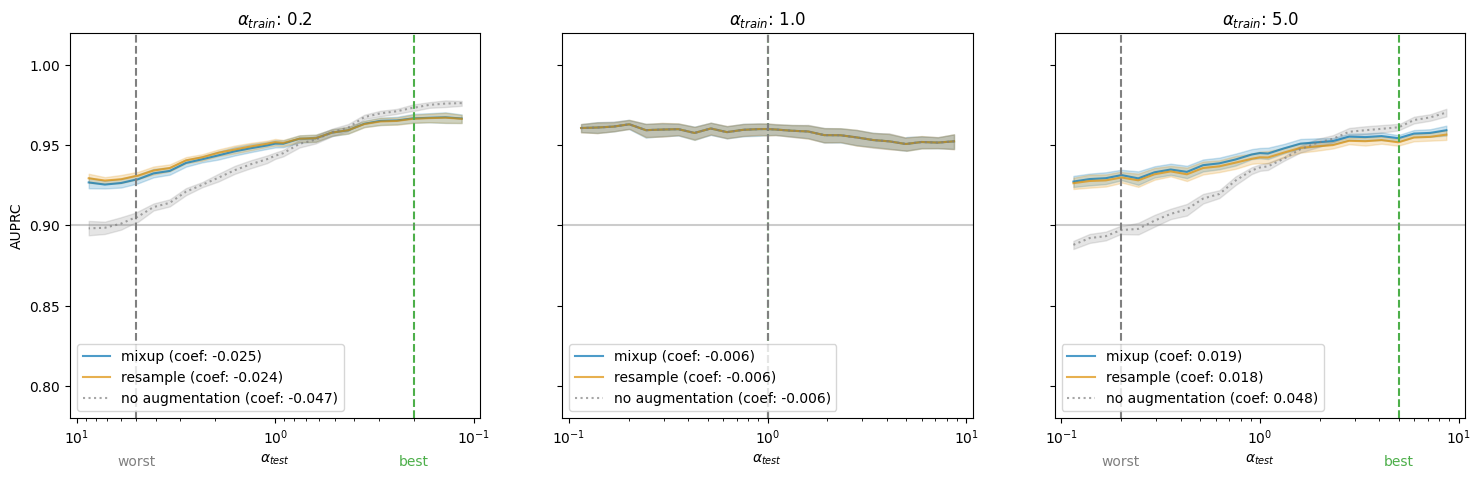

In [24]:
### C_y=0.3, C_z=0.5

C_y=0.5
C_z=0.5

savefig = False
# savefig = True


# alpha_train_ls = [0.2, 1, 5.0]
# set_ls = ["mixup_AugUp", "resample_AugUp", "noAug"]

# alpha_train_ls = [0.6667, 1, 1.5]
alpha_train_ls = [0.2, 1, 5]

set_name_fmt = {"mixup_AugUp": "mixup",
                "resample_AugUp": "resample", 
                "LLM_Generate_AugUp": "LLM generation", 
                "noAug": "no augmentation"}



if dataset_name in ['CD']:
    set_ls = ["mixup_AugUp", "resample_AugUp", "LLM_Generate_AugUp", "noAug"]
else:
    set_ls = ["mixup_AugUp", "resample_AugUp", "noAug"]


my_palette = sns.color_palette("colorblind", 5)
my_linestyle = ['solid','dotted']
xticks = [0.1,1,10]

xname = "alpha_test"
ylabel = "auprc_vanilla"
# ylabel = "auprc_backdoor"


outname = f"../output/DistMatchFigs/fig_{transform_method}_{dataset_name}_{ylabel}_Cz_{C_z}_Cy_{C_y}.png"



if dataset_name == "SHAC":
    y_lower = 0.78
    y_text = 0.75
    y_ref = 0.9
else:
    y_lower = -0.02
    y_text = -0.12
    y_ref = 0.6


_df = deepcopy(df_eval)

_df['C_y_test'] = _df['C_y_test'].round(2)
_df['alpha_train'] = _df['alpha_train'].round(4)

_df = _df[_df['dataset'] == dataset_name].query(f"C_y_test.isin([{C_y}])").query(f"C_z == {C_z}").reset_index(drop=True)


fig, ax = plt.subplots(1,3, figsize=(18,5), sharey=True)

for i, alpha_train in enumerate(alpha_train_ls):
    
    
    for idx_set, set_i in enumerate(set_ls):
        _df_plt = deepcopy(_df[(_df["alpha_train"] == alpha_train) & (_df["set"] == set_i)])
        # _df_plt = deepcopy(_df[ (_df["set"] == set_i)])

        
        if set_i == "noAug":
            c = 'gray'
            lst = 'dotted'
            
        else:
            c = my_palette[idx_set]
            lst = 'solid'
        
        print(len(_df_plt))
        _tmpForStats = _df_plt[_df_plt[xname] == 1/alpha_train][ylabel].describe()
        print(f"{alpha_train}: {set_i} : {_tmpForStats['mean']:.2f} \\pm {_tmpForStats['std']:.2f}")
        # _tmpForStats = _df_plt[_df_plt[xname] == 1/alpha_train][ylabel].describe()
        # print(f"{_tmpForStats['mean']:.2f}+{_tmpForStats['std']:.2f}")
        
        reg = get_coefLog10(x=list(_df_plt[xname]), y=list(_df_plt[ylabel]))

        sns.lineplot(data=_df_plt, x=xname, y=ylabel, ax=ax[i], 
                     c=c, 
                     linestyle=lst,
                     alpha=0.7,
                    #  linestyle=my_linestyle[ilambda], label=lambda_com + f" (coef: {reg[0]:.3f})"
                     label=set_name_fmt[set_i] + f" (coef: {reg[0]:.3f})"
                    )
        
       
        

    ax[i].set_xscale('log')
                 
    ax[i].axvline(alpha_train, color="#4DAF4A", linestyle='dashed')
    ax[i].axvline(1/alpha_train, color="gray", linestyle='dashed')
    if alpha_train != 1:
        ax[i].text(x=alpha_train, y=y_text, s='best', color="#4DAF4A", fontsize=10, horizontalalignment='center')
        ax[i].text(x=1/alpha_train, y=y_text, s='worst', color="gray", fontsize=10, horizontalalignment='center')

    ax[i].title.set_text(r"$\alpha_{train}$" + f": {alpha_train:.1f}")
    ax[i].set_ylim((y_lower,1.02))
    # ax[i].set_xticks(xticks)
    ax[i].legend(loc="lower left")
    ax[i].set_xlabel(r"$\alpha_{test}$")
    ax[i].set_ylabel("AUPRC")
    

    ax[i].axhline(y_ref, color="gray", alpha=0.4)        
    
    if alpha_train < 1:
        ax[i].invert_xaxis()
    
    
    

# plt.tight_layout()

if savefig:
    plt.savefig(outname, dpi=600, bbox_inches='tight')
else:
    plt.show()

plt.close()

## RoBERTa

In [3]:
set_name_fmt = {
                "mixup_AugUp": "mixup",
                "resample_AugUp": "resample", 
                "EDA_AugUp": "EDA", 
                "noAug": "no augmentation",
                "mixup by 4":"mixup-4 times",
                "ReSample by 4":"resample-4 times",
                "EDA by 4": "EDA-4 times",
                
                
                # "AllEqual-ReSample": "All Equal-Resample",
                
               }

1035
0.2: resample_AugUp : 0.89 \pm 0.03
1035
0.2: noAug : 0.91 \pm 0.02
1035
0.2: ReSample by 4 : 0.71 \pm 0.01
1035
5: resample_AugUp : 0.87 \pm 0.01
1035
5: noAug : 0.87 \pm 0.03
1035
5: ReSample by 4 : 0.47 \pm 0.02


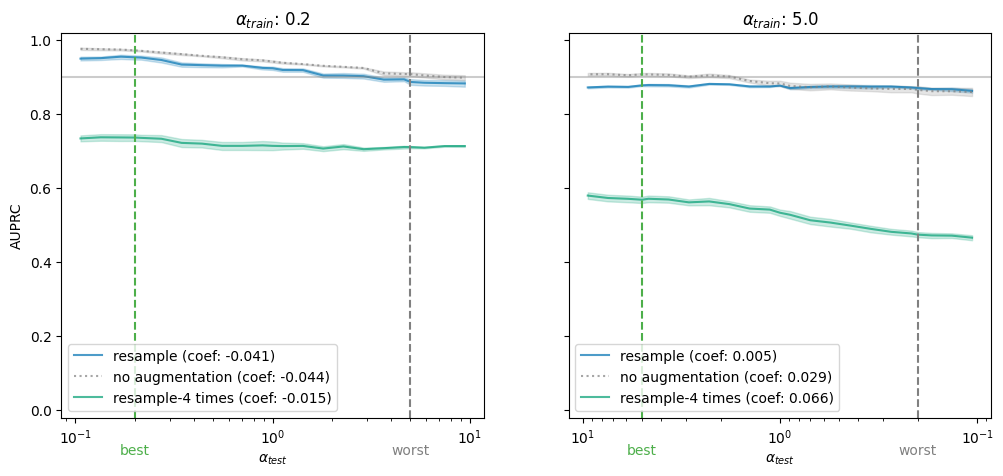

1035
0.2: mixup_AugUp : 0.95 \pm 0.01
1035
0.2: noAug : 0.91 \pm 0.02
1035
0.2: mixup by 4 : 0.96 \pm 0.01
1035
5: mixup_AugUp : 0.96 \pm 0.01
1035
5: noAug : 0.87 \pm 0.03
1035
5: mixup by 4 : 0.73 \pm 0.07


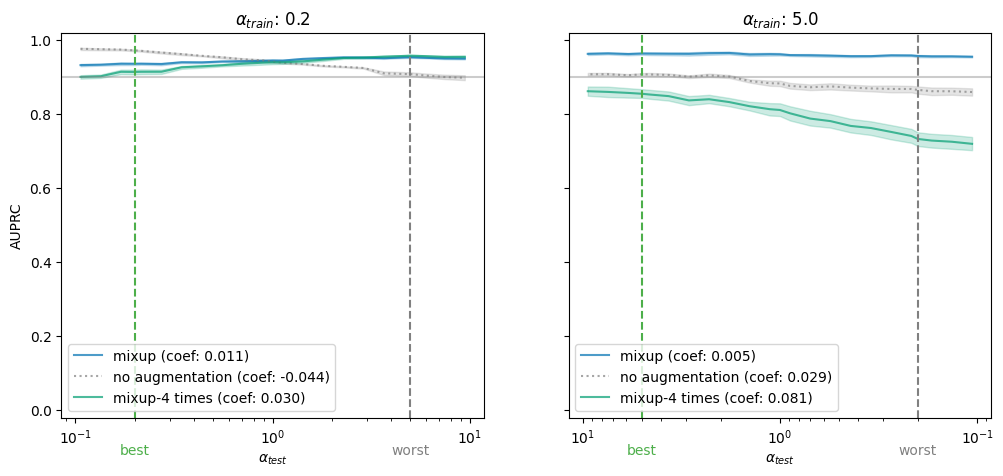

1035
0.2: EDA_AugUp : 0.92 \pm 0.01
1035
0.2: noAug : 0.91 \pm 0.02
1035
0.2: EDA by 4 : 0.69 \pm 0.04
1035
5: EDA_AugUp : 0.89 \pm 0.03
1035
5: noAug : 0.87 \pm 0.03
1035
5: EDA by 4 : 0.85 \pm 0.01


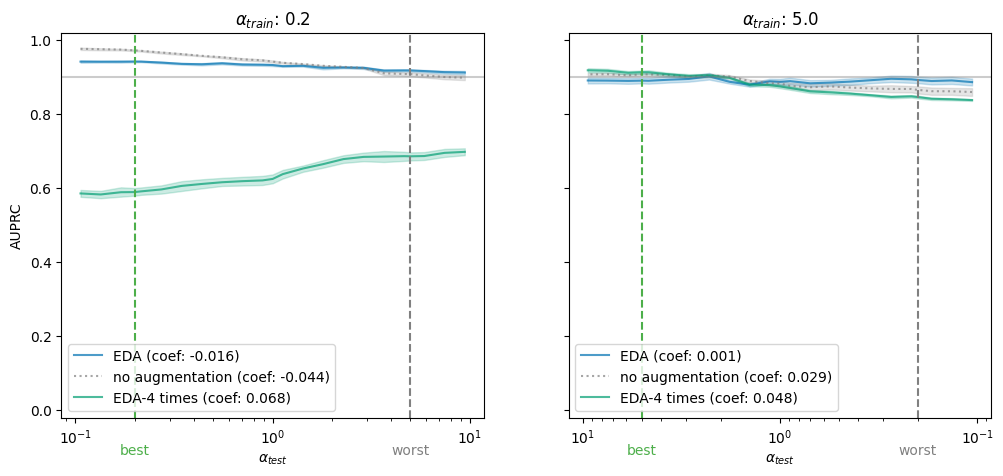

In [5]:
####----  Plot Separately
### C_y=0.3, C_z=0.5

C_y=0.5
C_z=0.5

savefig = False
# savefig = True

toPlot = "resample"

to_plot_DICT = {
        "resample": ["resample_AugUp", "noAug", "ReSample by 4"],
        "mixup": ["mixup_AugUp", "noAug", "mixup by 4"],
        "EDA":["EDA_AugUp", "noAug", "EDA by 4"],
                   }

for toPlot in to_plot_DICT.keys():
    

    # alpha_train_ls = [0.2, 1, 5.0]
    # set_ls = ["mixup_AugUp", "resample_AugUp", "noAug"]

    # alpha_train_ls = [0.6667, 1, 1.5]
    alpha_train_ls = [0.2, 5]

    set_name_fmt_reduce = {k:set_name_fmt[k] for k in to_plot_DICT[toPlot]}




    set_ls = list(set_name_fmt_reduce.keys())


    my_palette = sns.color_palette("colorblind")
    my_linestyle = ['solid','dotted']
    xticks = [0.1,1,10]

    xname = "alpha_test"
    ylabel = "auprc_weightsEdited"
    # ylabel = "auprc_backdoor"


    outname = f"../output/DistMatchFigs/RoBERTa/fig_{dataset_name}_-{toPlot}-{ylabel}_Cz_{C_z}_Cy_{C_y}.png"



    if dataset_name == "SHAC":
        y_lower = -0.02
        y_text = -0.12
        y_ref = 0.9
    else:
        y_lower = -0.02
        y_text = -0.12
        y_ref = 0.6


    _df = deepcopy(df_eval)

    _df['C_y_test'] = _df['C_y_test'].round(2)
    _df['alpha_train'] = _df['alpha_train'].round(4)

    _df = _df[_df['dataset'] == dataset_name].query(f"C_y_test.isin([{C_y}])").query(f"C_z == {C_z}").reset_index(drop=True)


    fig, ax = plt.subplots(1,2, figsize=(12,5), sharey=True)

    for i, alpha_train in enumerate(alpha_train_ls):


        for idx_set, set_i in enumerate(set_ls):
            _df_plt = deepcopy(_df[(_df["alpha_train"] == alpha_train) & (_df["set"] == set_i)])
            # _df_plt = deepcopy(_df[ (_df["set"] == set_i)])


            if set_i == "noAug":
                c = 'gray'
                lst = 'dotted'

            else:
                c = my_palette[idx_set]
                lst = 'solid'

            print(len(_df_plt))
            _tmpForStats = _df_plt[_df_plt[xname] == 1/alpha_train][ylabel].describe()
            print(f"{alpha_train}: {set_i} : {_tmpForStats['mean']:.2f} \\pm {_tmpForStats['std']:.2f}")

            reg = get_coefLog10(x=list(_df_plt[xname]), y=list(_df_plt[ylabel]))

            sns.lineplot(data=_df_plt, x=xname, y=ylabel, ax=ax[i], 
                         c=c, 
                         linestyle=lst,
                         alpha=0.7,
                        #  linestyle=my_linestyle[ilambda], label=lambda_com + f" (coef: {reg[0]:.3f})"
                         label=set_name_fmt_reduce[set_i] + f" (coef: {reg[0]:.3f})"
                        )




        ax[i].set_xscale('log')

        ax[i].axvline(alpha_train, color="#4DAF4A", linestyle='dashed')
        ax[i].axvline(1/alpha_train, color="gray", linestyle='dashed')
        if alpha_train != 1:
            ax[i].text(x=alpha_train, y=y_text, s='best', color="#4DAF4A", fontsize=10, horizontalalignment='center')
            ax[i].text(x=1/alpha_train, y=y_text, s='worst', color="gray", fontsize=10, horizontalalignment='center')

        ax[i].title.set_text(r"$\alpha_{train}$" + f": {alpha_train:.1f}")
        ax[i].set_ylim((y_lower,1.02))
        # ax[i].set_xticks(xticks)
        ax[i].legend(loc="lower left")
        ax[i].set_xlabel(r"$\alpha_{test}$")
        ax[i].set_ylabel("AUPRC")


        ax[i].axhline(y_ref, color="gray", alpha=0.4)        

        if alpha_train > 1:
            ax[i].invert_xaxis()




    # plt.tight_layout()

    if savefig:
        plt.savefig(outname, dpi=600, bbox_inches='tight')
    else:
        plt.show()

    plt.close()

0.94+0.01
0.95+0.02
0.94+0.01
0.97+0.01
0.91+0.02
0.74+0.03
0.59+0.03
0.96+0.01
0.88+0.01
0.89+0.03
0.91+0.01
0.86+0.04
0.57+0.03
0.91+0.02


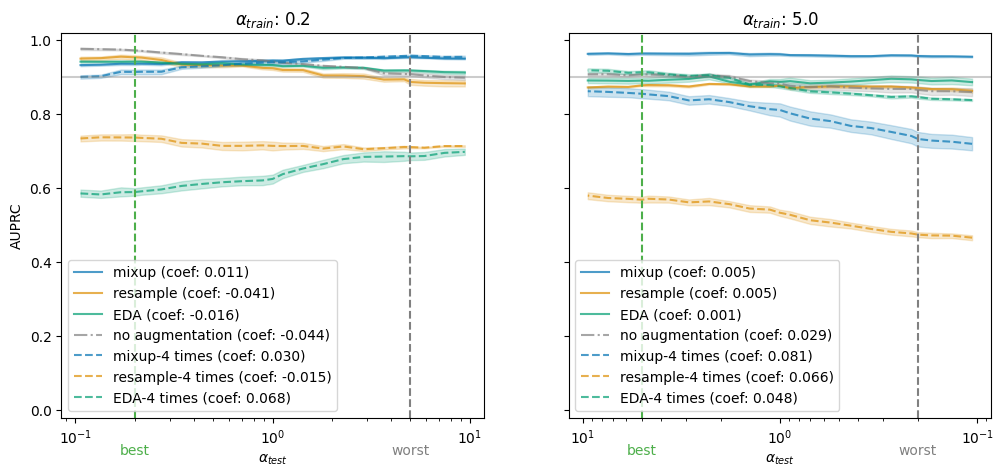

In [11]:
####----  Plot all
### C_y=0.3, C_z=0.5

C_y=0.5
C_z=0.5

savefig = False
# savefig = True


# alpha_train_ls = [0.2, 1, 5.0]
# set_ls = ["mixup_AugUp", "resample_AugUp", "noAug"]

# alpha_train_ls = [0.6667, 1, 1.5]
alpha_train_ls = [0.2, 5]



set_ls = list(set_name_fmt.keys())


# my_palette = sns.color_palette("colorblind")

lst = ["solid", "solid", "solid", "dashdot", "dashed", "dashed", "dashed"]
my_palette = [sns.color_palette("colorblind")[_] for _ in [0,1,2,3,0,1,2]]

xticks = [0.1,1,10]

xname = "alpha_test"
ylabel = "auprc_weightsEdited"
# ylabel = "auprc_backdoor"


outname = f"../output/DistMatchFigs/RoBERTa/fig_DistMatch-{dataset_name}_DistMatchEp_{ep}-By4Ep_{ep_by4}-Cz_{C_z}_Cy_{C_y}.png"



if dataset_name == "SHAC":
    y_lower = -0.02
    y_text = -0.12
    y_ref = 0.9
else:
    y_lower = -0.02
    y_text = -0.12
    y_ref = 0.6


_df = deepcopy(df_eval)

_df['C_y_test'] = _df['C_y_test'].round(2)
_df['alpha_train'] = _df['alpha_train'].round(4)

_df = _df[_df['dataset'] == dataset_name].query(f"C_y_test.isin([{C_y}])").query(f"C_z == {C_z}").reset_index(drop=True)


fig, ax = plt.subplots(1,2, figsize=(12,5), sharey=True)

for i, alpha_train in enumerate(alpha_train_ls):
    
    
    for idx_set, set_i in enumerate(set_ls):
        _df_plt = deepcopy(_df[(_df["alpha_train"] == alpha_train) & (_df["set"] == set_i)])
        # _df_plt = deepcopy(_df[ (_df["set"] == set_i)])

        
        if set_i == "noAug":
            c = 'gray'
            # lst = 'dotted'
            
        else:
            c = my_palette[idx_set]
            # lst = 'solid'
        
        print(len(_df_plt))
        _tmpForStats = _df_plt[_df_plt[xname] == 1/alpha_train][ylabel].describe()
        print(f"{alpha_train}: {set_i} : {_tmpForStats['mean']:.2f} \\pm {_tmpForStats['std']:.2f}")
        
        # _tmpForStats = _df_plt[_df_plt[xname] == alpha_train][ylabel].describe()
        # print(f"{_tmpForStats['mean']:.2f}+{_tmpForStats['std']:.2f}")
        
        reg = get_coefLog10(x=list(_df_plt[xname]), y=list(_df_plt[ylabel]))

        sns.lineplot(data=_df_plt, x=xname, y=ylabel, ax=ax[i], 
                     c=c, 
                     linestyle=lst[idx_set],
                     alpha=0.7,
                    #  linestyle=my_linestyle[ilambda], label=lambda_com + f" (coef: {reg[0]:.3f})"
                     label=set_name_fmt[set_i] + f" (coef: {reg[0]:.3f})"
                    )
        
       
        

    ax[i].set_xscale('log')
                 
    ax[i].axvline(alpha_train, color="#4DAF4A", linestyle='dashed')
    ax[i].axvline(1/alpha_train, color="gray", linestyle='dashed')
    if alpha_train != 1:
        ax[i].text(x=alpha_train, y=y_text, s='best', color="#4DAF4A", fontsize=10, horizontalalignment='center')
        ax[i].text(x=1/alpha_train, y=y_text, s='worst', color="gray", fontsize=10, horizontalalignment='center')

    ax[i].title.set_text(r"$\alpha_{train}$" + f": {alpha_train:.1f}")
    ax[i].set_ylim((y_lower,1.02))
    # ax[i].set_xticks(xticks)
    ax[i].legend(loc="lower left")
    ax[i].set_xlabel(r"$\alpha_{test}$")
    ax[i].set_ylabel("AUPRC")
    

    ax[i].axhline(y_ref, color="gray", alpha=0.4)        
    
    if alpha_train > 1:
        ax[i].invert_xaxis()
    
    
    

# plt.tight_layout()

if savefig:
    plt.savefig(outname, dpi=600, bbox_inches='tight')
else:
    plt.show()

plt.close()

In [7]:
dataset_name

'SHAC'

## baseline + MMD + GDRO + DANN

0.95+0.01
0.90+0.03
0.78+0.04
0.88+0.03
0.96+0.01
0.89+0.02
0.80+0.04
0.88+0.02


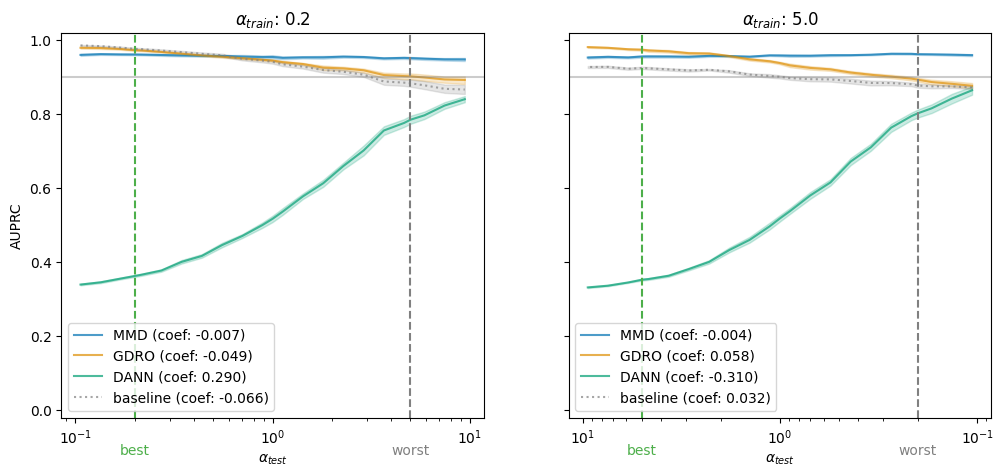

In [12]:
### C_y=0.3, C_z=0.5

C_y=0.5
C_z=0.5

savefig = False
# savefig = True


# alpha_train_ls = [0.2, 1, 5.0]
# set_ls = ["mixup_AugUp", "resample_AugUp", "noAug"]

# alpha_train_ls = [0.6667, 1, 1.5]
alpha_train_ls = [0.2, 5]

set_name_fmt = {"mmd": "MMD", 
                "gdro": "GDRO",
                "Gradient Reverse": "DANN",
                # "Gradient Reverse ForDomainBed": "DANN-DB",
                "noAug": "baseline",
                
                
               }

set_ls = list(set_name_fmt.keys())


my_palette = sns.color_palette("colorblind", 5)
my_linestyle = ['solid','dotted']
xticks = [0.1,1,10]

xname = "alpha_test"
ylabel = "auprc_weightsEdited"
# ylabel = "auprc_backdoor"


outname = f"../output/MMD_GDRO_GradReverse_Figs/RoBERTa/fig_MMD_GDRO_GradReverse_{dataset_name}_{ylabel}_Cz_{C_z}_Cy_{C_y}.png"



if dataset_name == "SHAC":
    y_lower = -0.02
    y_text = -0.12
    y_ref = 0.9
else:
    y_lower = -0.02
    y_text = -0.12
    y_ref = 0.6


_df = deepcopy(df_eval)

_df['C_y_test'] = _df['C_y_test'].round(2)
_df['alpha_train'] = _df['alpha_train'].round(4)

_df = _df[_df['dataset'] == dataset_name].query(f"C_y_test.isin([{C_y}])").query(f"C_z == {C_z}").reset_index(drop=True)


fig, ax = plt.subplots(1,2, figsize=(12,5), sharey=True)

for i, alpha_train in enumerate(alpha_train_ls):
    
    
    for idx_set, set_i in enumerate(set_ls):
        _df_plt = deepcopy(_df[(_df["alpha_train"] == alpha_train) & (_df["set"] == set_i)])
        # _df_plt = deepcopy(_df[ (_df["set"] == set_i)])

        
        if set_i == "noAug":
            c = 'gray'
            lst = 'dotted'
            
        else:
            c = my_palette[idx_set]
            lst = 'solid'
        
#         print(len(_df_plt))
#         _tmpForStats = _df_plt[_df_plt[xname] == 1/alpha_train][ylabel].describe()
#         print(f"{alpha_train}: {set_i} : {_tmpForStats['mean']:.2f} \\pm {_tmpForStats['std']:.2f}")
        
        
        
        _tmpForStats = _df_plt[_df_plt[xname] == 1/alpha_train][ylabel].describe()
        print(f"{_tmpForStats['mean']:.2f}+{_tmpForStats['std']:.2f}")
        
        reg = get_coefLog10(x=list(_df_plt[xname]), y=list(_df_plt[ylabel]))

        sns.lineplot(data=_df_plt, x=xname, y=ylabel, ax=ax[i], 
                     c=c, 
                     linestyle=lst,
                     alpha=0.7,
                    #  linestyle=my_linestyle[ilambda], label=lambda_com + f" (coef: {reg[0]:.3f})"
                     label=set_name_fmt[set_i] + f" (coef: {reg[0]:.3f})"
                    )
        
       
        

    ax[i].set_xscale('log')
                 
    ax[i].axvline(alpha_train, color="#4DAF4A", linestyle='dashed')
    ax[i].axvline(1/alpha_train, color="gray", linestyle='dashed')
    if alpha_train != 1:
        ax[i].text(x=alpha_train, y=y_text, s='best', color="#4DAF4A", fontsize=10, horizontalalignment='center')
        ax[i].text(x=1/alpha_train, y=y_text, s='worst', color="gray", fontsize=10, horizontalalignment='center')

    ax[i].title.set_text(r"$\alpha_{train}$" + f": {alpha_train:.1f}")
    ax[i].set_ylim((y_lower,1.02))
    # ax[i].set_xticks(xticks)
    ax[i].legend(loc="lower left")
    ax[i].set_xlabel(r"$\alpha_{test}$")
    ax[i].set_ylabel("AUPRC")
    

    ax[i].axhline(y_ref, color="gray", alpha=0.4)        
    
    if alpha_train > 1:
        ax[i].invert_xaxis()
    
    
    

# plt.tight_layout()

if savefig:
    plt.savefig(outname, dpi=600, bbox_inches='tight')
else:
    plt.show()

plt.close()

In [13]:
dataset_name

'SHAC'

In [14]:
set_ls

['mmd', 'gdro', 'Gradient Reverse', 'noAug']

0.61+0.03
0.50+0.03
0.74+0.03
0.55+0.03
0.51+0.04


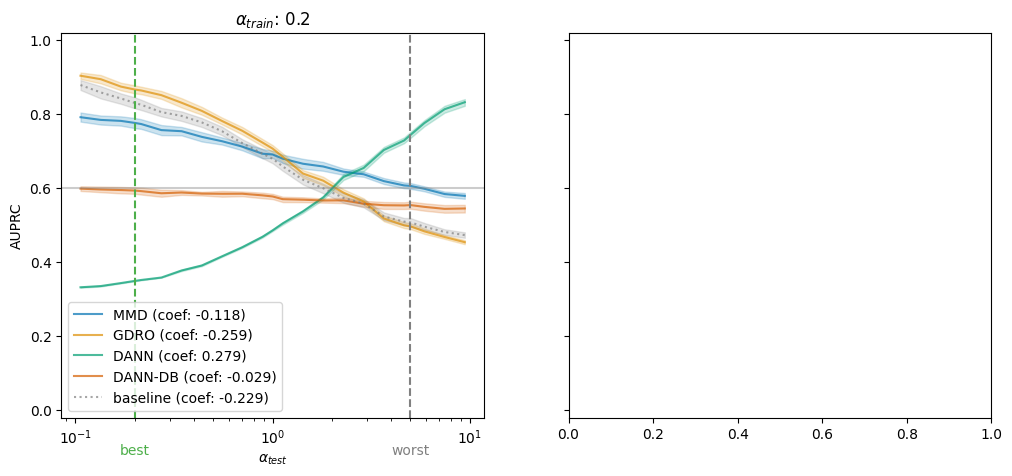

In [5]:
#### Test for Yongsen's Setting ONLY!!!!!!!!
### C_y=0.3, C_z=0.5

C_y=0.5
C_z=0.5

savefig = False
# savefig = True

alpha_train_ls = [0.2]

set_name_fmt = {"mmd": "MMD", 
                "gdro": "GDRO",
                "Gradient Reverse": "DANN",
                "Gradient Reverse ForDomainBed": "DANN-DB",
                "noAug": "baseline",
                
                
               }

set_ls = list(set_name_fmt.keys())


my_palette = sns.color_palette("colorblind", 5)
my_linestyle = ['solid','dotted']
xticks = [0.1,1,10]

xname = "alpha_test"
ylabel = "auprc_weightsEdited"
# ylabel = "auprc_backdoor"


outname = f"../output/MMD_GDRO_GradReverse_Figs/RoBERTa/fig_MMD_GDRO_GradReverse_{dataset_name}_{ylabel}_Cz_{C_z}_Cy_{C_y}.png"



if dataset_name == "SHAC":
    y_lower = -0.02
    y_text = -0.12
    y_ref = 0.9
else:
    y_lower = -0.02
    y_text = -0.12
    y_ref = 0.6


_df = deepcopy(df_eval)

_df['C_y_test'] = _df['C_y_test'].round(2)
_df['alpha_train'] = _df['alpha_train'].round(4)

_df = _df[_df['dataset'] == dataset_name].query(f"C_y_test.isin([{C_y}])").query(f"C_z == {C_z}").reset_index(drop=True)


fig, ax = plt.subplots(1,2, figsize=(12,5), sharey=True)

for i, alpha_train in enumerate(alpha_train_ls):
    
    
    for idx_set, set_i in enumerate(set_ls):
        _df_plt = deepcopy(_df[(_df["alpha_train"] == alpha_train) & (_df["set"] == set_i)])
        # _df_plt = deepcopy(_df[ (_df["set"] == set_i)])

        
        if set_i == "noAug":
            c = 'gray'
            lst = 'dotted'
            
        else:
            c = my_palette[idx_set]
            lst = 'solid'
        
#         print(len(_df_plt))
#         _tmpForStats = _df_plt[_df_plt[xname] == 1/alpha_train][ylabel].describe()
#         print(f"{alpha_train}: {set_i} : {_tmpForStats['mean']:.2f} \\pm {_tmpForStats['std']:.2f}")
        
        
        
        _tmpForStats = _df_plt[_df_plt[xname] == 1/alpha_train][ylabel].describe()
        print(f"{_tmpForStats['mean']:.2f}+{_tmpForStats['std']:.2f}")
        
        reg = get_coefLog10(x=list(_df_plt[xname]), y=list(_df_plt[ylabel]))

        sns.lineplot(data=_df_plt, x=xname, y=ylabel, ax=ax[i], 
                     c=c, 
                     linestyle=lst,
                     alpha=0.7,
                    #  linestyle=my_linestyle[ilambda], label=lambda_com + f" (coef: {reg[0]:.3f})"
                     label=set_name_fmt[set_i] + f" (coef: {reg[0]:.3f})"
                    )
        
       
        

    ax[i].set_xscale('log')
                 
    ax[i].axvline(alpha_train, color="#4DAF4A", linestyle='dashed')
    ax[i].axvline(1/alpha_train, color="gray", linestyle='dashed')
    if alpha_train != 1:
        ax[i].text(x=alpha_train, y=y_text, s='best', color="#4DAF4A", fontsize=10, horizontalalignment='center')
        ax[i].text(x=1/alpha_train, y=y_text, s='worst', color="gray", fontsize=10, horizontalalignment='center')

    ax[i].title.set_text(r"$\alpha_{train}$" + f": {alpha_train:.1f}")
    ax[i].set_ylim((y_lower,1.02))
    # ax[i].set_xticks(xticks)
    ax[i].legend(loc="lower left")
    ax[i].set_xlabel(r"$\alpha_{test}$")
    ax[i].set_ylabel("AUPRC")
    

    ax[i].axhline(y_ref, color="gray", alpha=0.4)        
    
    if alpha_train > 1:
        ax[i].invert_xaxis()
    
    
    

# plt.tight_layout()

if savefig:
    plt.savefig(outname, dpi=600, bbox_inches='tight')
else:
    plt.show()

plt.close()

# Plot - Vanilla and Backdoor, separately

In [43]:
sns.reset_defaults()
sns.set_theme(style="ticks", rc={"figure.dpi": 350})


In [ ]:
### C_y=0.3, C_z=0.5

savefig = False
# savefig = True


# alpha_train_ls = [0.2, 1, 5.0]
# set_ls = ["mixup_AugUp", "resample_AugUp", "noAug"]

# alpha_train_ls = [0.6667, 1, 1.5]
alpha_train_ls = [0.1, 1, 10]

set_ls = ["mixup_AugUp", "resample_AugUp", "noAug"]

# set_ls = ["mixup_AugUp", "reverseTranslate_AugUp", "resample_AugUp", "noAug"]

my_palette = sns.color_palette("colorblind", 5)
my_linestyle = ['solid','dotted']
xticks = [0.1,1,10]

xname = "alpha_test"
ylabel = "auprc_vanilla"
# ylabel = "auprc_backdoor"


outname = f"../output/tmpFig/fig_XXX_{dataset_name}_Cz_0.5_Cy_0.3.png"




_df = deepcopy(df_eval)

_df['C_y'] = _df['C_y'].round(2)
_df['alpha_train'] = _df['alpha_train'].round(4)

_df = _df[_df['dataset'] == dataset_name].query("C_y.isin([0.3])").query("C_z == 0.5").reset_index(drop=True)


fig, ax = plt.subplots(1,3, figsize=(14,4), sharey=True)

for i, alpha_train in enumerate(alpha_train_ls):
    
    
    for idx_set, set_i in enumerate(set_ls):
        _df_plt = deepcopy(_df[(_df["alpha_train"] == alpha_train) & (_df["set"] == set_i)])
        
        if set_i == "noAug":
            c = 'gray'
            lst = 'dotted'
            
        else:
            c = my_palette[idx_set]
            lst = 'solid'
        
        print(len(_df_plt))
        reg = get_coefLog10(x=list(_df_plt[xname]), y=list(_df_plt[ylabel]))

        sns.lineplot(data=_df_plt, x=xname, y=ylabel, ax=ax[i], 
                     c=c, 
                     linestyle=lst,
                     alpha=0.7,
                    #  linestyle=my_linestyle[ilambda], label=lambda_com + f" (coef: {reg[0]:.3f})"
                     label=set_i + f" (coef: {reg[0]:.3f})"
                    )
        
       
        

    ax[i].set_xscale('log')
                 
    ax[i].axvline(alpha_train, color="#4DAF4A", linestyle='dashed')
    ax[i].axvline(1/alpha_train, color="gray", linestyle='dashed')
    if alpha_train != 1:
        ax[i].text(x=alpha_train, y=-0.12, s='best', color="#4DAF4A", fontsize=10, horizontalalignment='center')
        ax[i].text(x=1/alpha_train, y=-0.12, s='worst', color="gray", fontsize=10, horizontalalignment='center')

    ax[i].title.set_text(r"$\alpha_{train}$" + f": {alpha_train:.1f}")
    ax[i].set_ylim((-0.02,1.02))
    # ax[i].set_xticks(xticks)
    ax[i].legend(loc="lower left")
    ax[i].set_xlabel(r"$\alpha_{test}$")
    ax[i].set_ylabel("AUPRC")
    
    ax[i].axhline(0.6, color="gray", alpha=0.4)
    
    if alpha_train < 1:
        ax[i].invert_xaxis()
    
    
    

# plt.tight_layout()

if savefig:
    plt.savefig(outname, dpi=600, bbox_inches='tight')
else:
    plt.show()

plt.close()

2700
2700
2700
2700
2700
2700


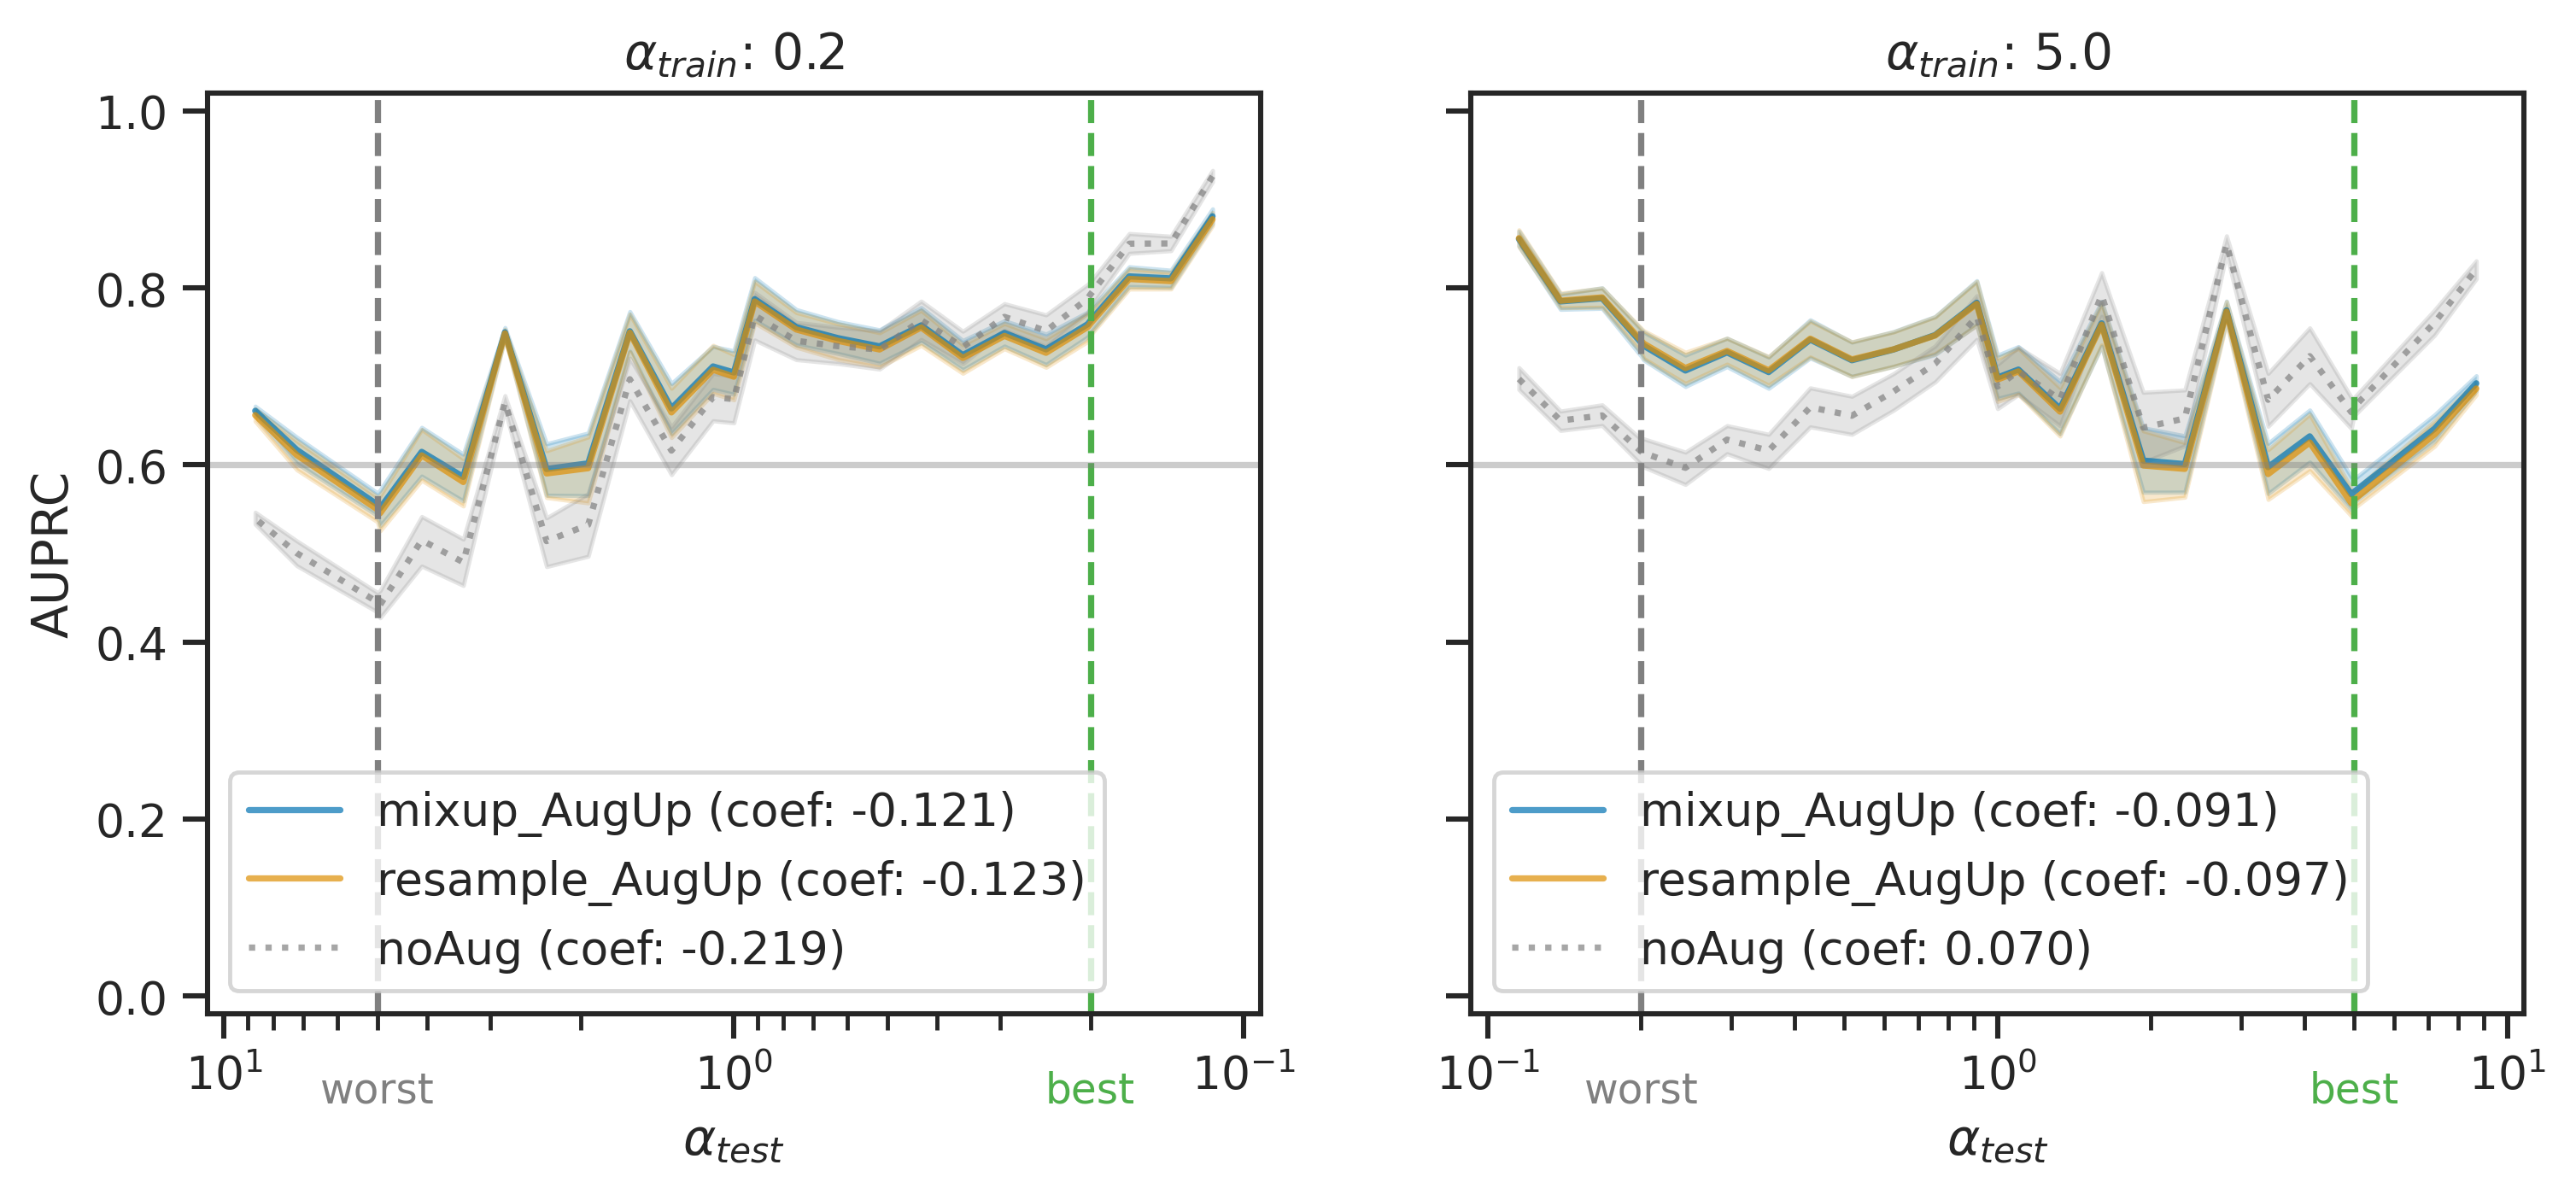

In [64]:
### without alpha_train = 1


### C_y=0.42, C_z=0.5


savefig = False
# savefig = True


alpha_train_ls = [0.2, 5.0]
set_ls = ["mixup_AugUp", "resample_AugUp", "noAug"]

my_palette = sns.color_palette("colorblind", 5)
my_linestyle = ['solid','dotted']
xticks = [0.1,1,10]

xname = "alpha_test"
ylabel = "auprc_vanilla"
# ylabel = "auprc_backdoor"


outname = f"../output/tmpFig/fig_XXX_{dataset_name}_Cz_0.5_Cy_0.42.png"




_df = deepcopy(df_eval)

_df['C_y'] = _df['C_y'].round(2)

_df = _df[_df['dataset'] == dataset_name].query("C_y.isin([0.3])").query("C_z == 0.5").reset_index(drop=True)


fig, ax = plt.subplots(1,2, figsize=(10,4), sharey=True)

for i, alpha_train in enumerate(alpha_train_ls):
    
    
    for idx_set, set_i in enumerate(set_ls):
        _df_plt = deepcopy(_df[(_df["alpha_train"] == alpha_train) & (_df["set"] == set_i)])
        
        if set_i == "noAug":
            c = 'gray'
            lst = 'dotted'
            
        else:
            c = my_palette[idx_set]
            lst = 'solid'
        
        print(len(_df_plt))
        reg = get_coefLog10(x=list(_df_plt[xname]), y=list(_df_plt[ylabel]))

        sns.lineplot(data=_df_plt, x=xname, y=ylabel, ax=ax[i], 
                     c=c, 
                     linestyle=lst,
                     alpha=0.7,
                    #  linestyle=my_linestyle[ilambda], label=lambda_com + f" (coef: {reg[0]:.3f})"
                     label=set_i + f" (coef: {reg[0]:.3f})"
                    )
        
       
        

    ax[i].set_xscale('log')
                 
    ax[i].axvline(alpha_train, color="#4DAF4A", linestyle='dashed')
    ax[i].axvline(1/alpha_train, color="gray", linestyle='dashed')
    if alpha_train != 1:
        ax[i].text(x=alpha_train, y=-0.12, s='best', color="#4DAF4A", fontsize=10, horizontalalignment='center')
        ax[i].text(x=1/alpha_train, y=-0.12, s='worst', color="gray", fontsize=10, horizontalalignment='center')

    ax[i].title.set_text(r"$\alpha_{train}$" + f": {alpha_train:.1f}")
    ax[i].set_ylim((-0.02,1.02))
    # ax[i].set_xticks(xticks)
    ax[i].legend(loc="lower left")
    ax[i].set_xlabel(r"$\alpha_{test}$")
    ax[i].set_ylabel("AUPRC")
    
    ax[i].axhline(0.6, color="gray", alpha=0.4)
    
    if alpha_train < 1:
        ax[i].invert_xaxis()
    
    
    

# plt.tight_layout()

if savefig:
    plt.savefig(outname, dpi=600, bbox_inches='tight')
else:
    plt.show()

plt.close()

# Check by Subgroup

In [3]:
sns.reset_defaults()
sns.set_theme(style="ticks", rc={"figure.dpi": 350})


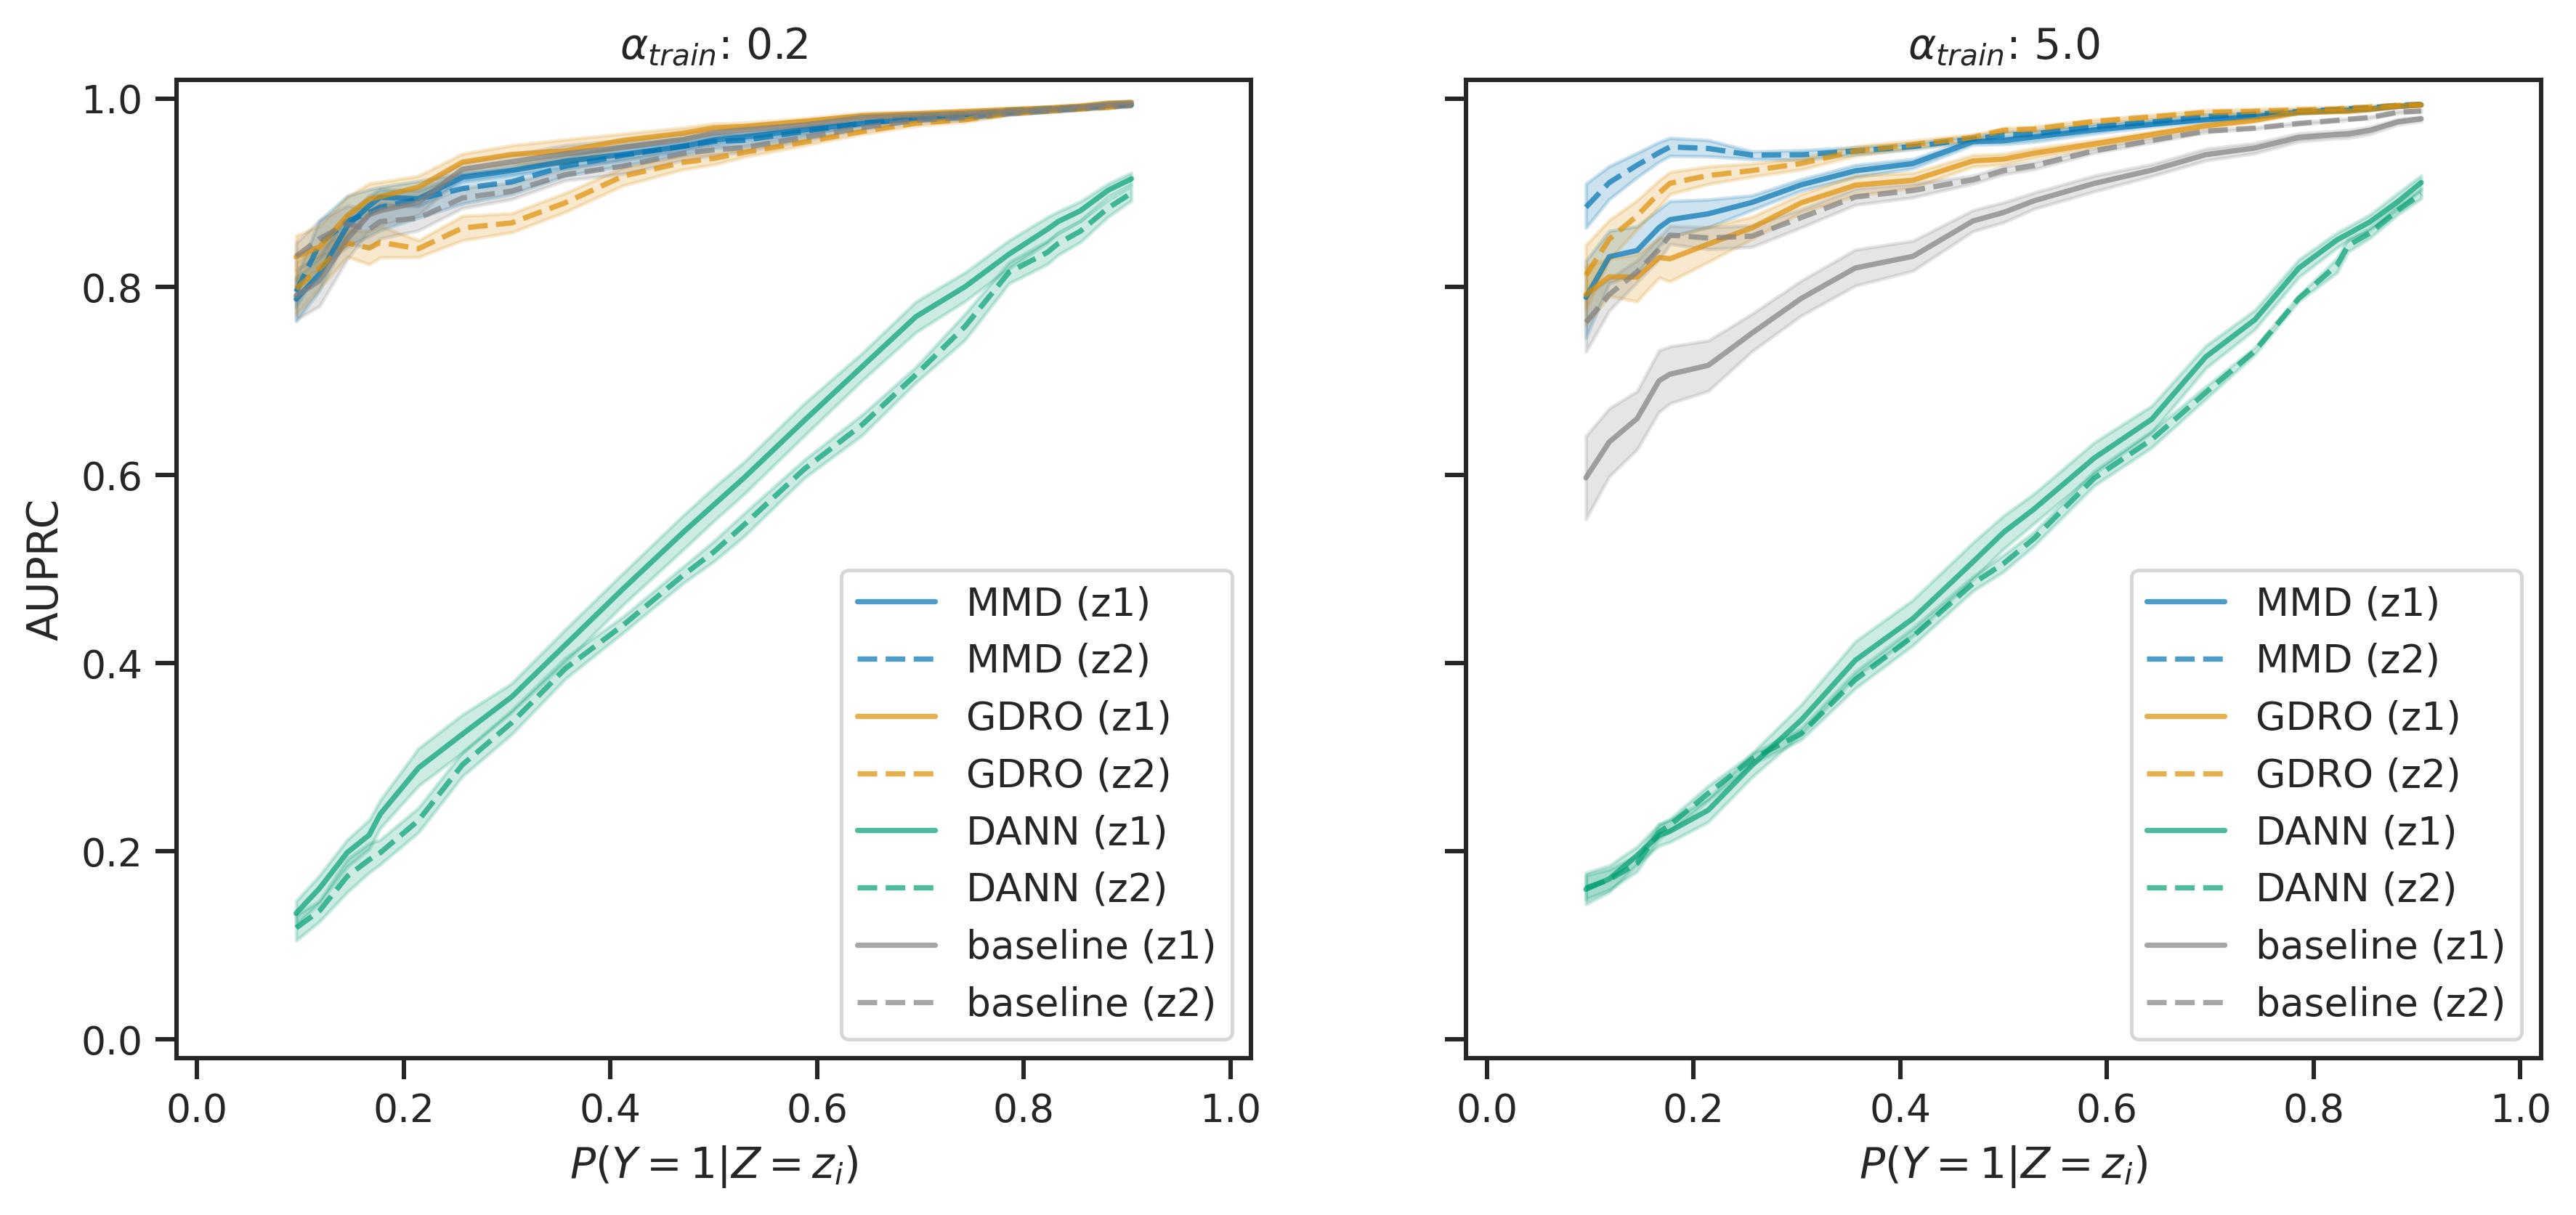

In [5]:
### C_y=0.3, C_z=0.5

C_y=0.5
C_z=0.5

savefig = False
# savefig = True


# alpha_train_ls = [0.2, 1, 5.0]
# set_ls = ["mixup_AugUp", "resample_AugUp", "noAug"]

# alpha_train_ls = [0.6667, 1, 1.5]
alpha_train_ls = [0.2, 5]

set_name_fmt = {"mmd": "MMD", 
                "gdro": "GDRO",
                "Gradient Reverse": "DANN",
                "noAug": "baseline",
                
                
               }

set_ls = list(set_name_fmt.keys())


my_palette = sns.color_palette("colorblind", 5)
my_linestyle = ['solid','dotted']
xticks = [0.1,1,10]

# ylabel = "auprc_backdoor"


outname = f"../output/MMD_GDRO_GradReverse_Figs/RoBERTa/fig-byProvenance-MMD_GDRO_GradReverse_{dataset_name}_Cz_{C_z}_Cy_{C_y}.png"


if dataset_name == "SHAC":
    y_lower = -0.02
    y_text = -0.12
    y_ref = 0.9
else:
    y_lower = -0.02
    y_text = -0.12
    y_ref = 0.6


_df = deepcopy(df_eval)

_df['C_y_test'] = _df['C_y_test'].round(2)
_df['alpha_train'] = _df['alpha_train'].round(4)

_df = _df[_df['dataset'] == dataset_name].query(f"C_y_test.isin([{C_y}])").query(f"C_z == {C_z}").reset_index(drop=True)
# _df = _df[_df['dataset'] == dataset_name].query(f"C_z == {C_z}").reset_index(drop=True)


fig, ax = plt.subplots(1,2, figsize=(12,5), sharey=True)

for i, alpha_train in enumerate(alpha_train_ls):
    
    
    for idx_set, set_i in enumerate(set_ls):
        
        
        _df_plt = deepcopy(_df[(_df["alpha_train"] == alpha_train) & (_df["set"] == set_i)])
        
        
        
        for xname, _ylabel, lst, nm_suffix in zip(['p_pos_test_z0', 'p_pos_test_z1'], ["auprc_weightsEdited_df0", "auprc_weightsEdited_df1"], ['solid', 'dashed'], ['z1', 'z2']):
        # for xname, _ylabel, lst in zip(['p_pos_test_z1'], [ylabel_1], ['solid']):


            # print(len(_df_plt))
            # _tmpForStats = _df_plt[_df_plt[xname] == 1/alpha_train][_ylabel].describe()
            # print(f"{alpha_train}: {set_i} : {_tmpForStats['mean']:.2f} \\pm {_tmpForStats['std']:.2f}")

            # reg = get_coefLog10(x=list(_df_plt[xname]), y=list(_df_plt[_ylabel]))

            if set_i == "noAug":
                c = 'gray'
                # lst = 'dotted'

            else:
                c = my_palette[idx_set]
                            
            sns.lineplot(data=_df_plt, x=xname, y=_ylabel, ax=ax[i], 
                         c=c, 
                         linestyle=lst,
                         alpha=0.7,
                        #  linestyle=my_linestyle[ilambda], label=lambda_com + f" (coef: {reg[0]:.3f})"
                         label=set_name_fmt[set_i]  + f" ({nm_suffix})"
                        )
        
       
        

    # ax[i].set_xscale('log')
                 
    # ax[i].axvline(alpha_train, color="#4DAF4A", linestyle='dashed')
    # ax[i].axvline(1/alpha_train, color="gray", linestyle='dashed')
    # if alpha_train != 1:
    #     ax[i].text(x=alpha_train, y=y_text, s='best', color="#4DAF4A", fontsize=10, horizontalalignment='center')
    #     ax[i].text(x=1/alpha_train, y=y_text, s='worst', color="gray", fontsize=10, horizontalalignment='center')

    ax[i].title.set_text(r"$\alpha_{train}$" + f": {alpha_train:.1f}")
    ax[i].set_ylim((-0.02,1.02))
    ax[i].set_xlim((-0.02,1.02))
    # ax[i].set_xticks(xticks)
    ax[i].legend(loc="lower right")
    ax[i].set_xlabel(r"$P(Y=1|Z=z_i)$")
    ax[i].set_ylabel("AUPRC")
    

#     ax[i].axhline(y_ref, color="gray", alpha=0.4)        
    
#     if alpha_train > 1:
#         ax[i].invert_xaxis()
    
    
    

# plt.tight_layout()

if savefig:
    plt.savefig(outname, dpi=600, bbox_inches='tight')
else:
    plt.show()

plt.close()

In [21]:
dataset_name

'HateSpeech'

In [21]:
sum((df_eval['p_mix_z0'] * df_eval['p_pos_test_z0'] + df_eval['p_mix_z1'] * df_eval['p_pos_test_z1'] ).round(2) != df_eval['C_y_test'].round(2))

0

In [28]:
sum(df_eval.query(f"C_z == {C_z}")['p_mix_z0'] != 0.5)

0

# Some diag...

In [76]:
sns.reset_defaults()


In [77]:
_df = deepcopy(df_eval)

_df = _df[_df['dataset'] == dataset_name].query("C_y.isin([0.3])").query("C_z == 0.5").reset_index(drop=True)


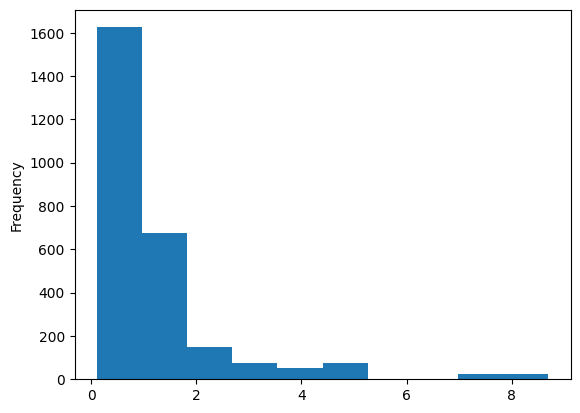

In [80]:
_df.query("set == 'mixup_AugUp'").query("alpha_train == 5")["alpha_test"].plot.hist()
plt.show()

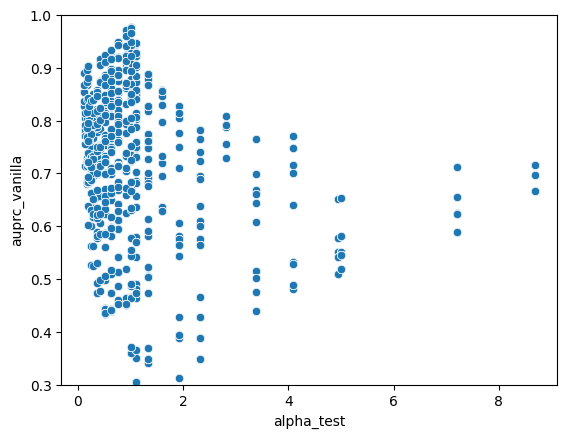

In [114]:
fig, ax = plt.subplots(1,1)

sns.scatterplot(_df.query("set == 'mixup_AugUp'").query("alpha_train == 5"), x='alpha_test', y='auprc_vanilla',ax=ax)
# ax.set_xscale('log')
ax.set_ylim(0.3,1)
plt.show()


In [121]:
_df.query("set == 'mixup_AugUp'").query("alpha_train == 5").query("1<alpha_test<5").groupby(['alpha_test', 'p_pos_test_z1', 'p_pos_test_z0']).size()

alpha_test  p_pos_test_z1  p_pos_test_z0
1.098541    0.109854       0.1              25
            0.219708       0.2              25
            0.329562       0.3              25
            0.439416       0.4              25
            0.549271       0.5              25
            0.659125       0.6              25
            0.768979       0.7              25
            0.878833       0.8              25
1.325711    0.132571       0.1              25
            0.265142       0.2              25
            0.397713       0.3              25
            0.530285       0.4              25
            0.662856       0.5              25
            0.795427       0.6              25
1.599859    0.479958       0.3              25
            0.799929       0.5              25
1.930698    0.193070       0.1              25
            0.386140       0.2              25
            0.772279       0.4              25
2.329952    0.232995       0.1              25
            0.46599

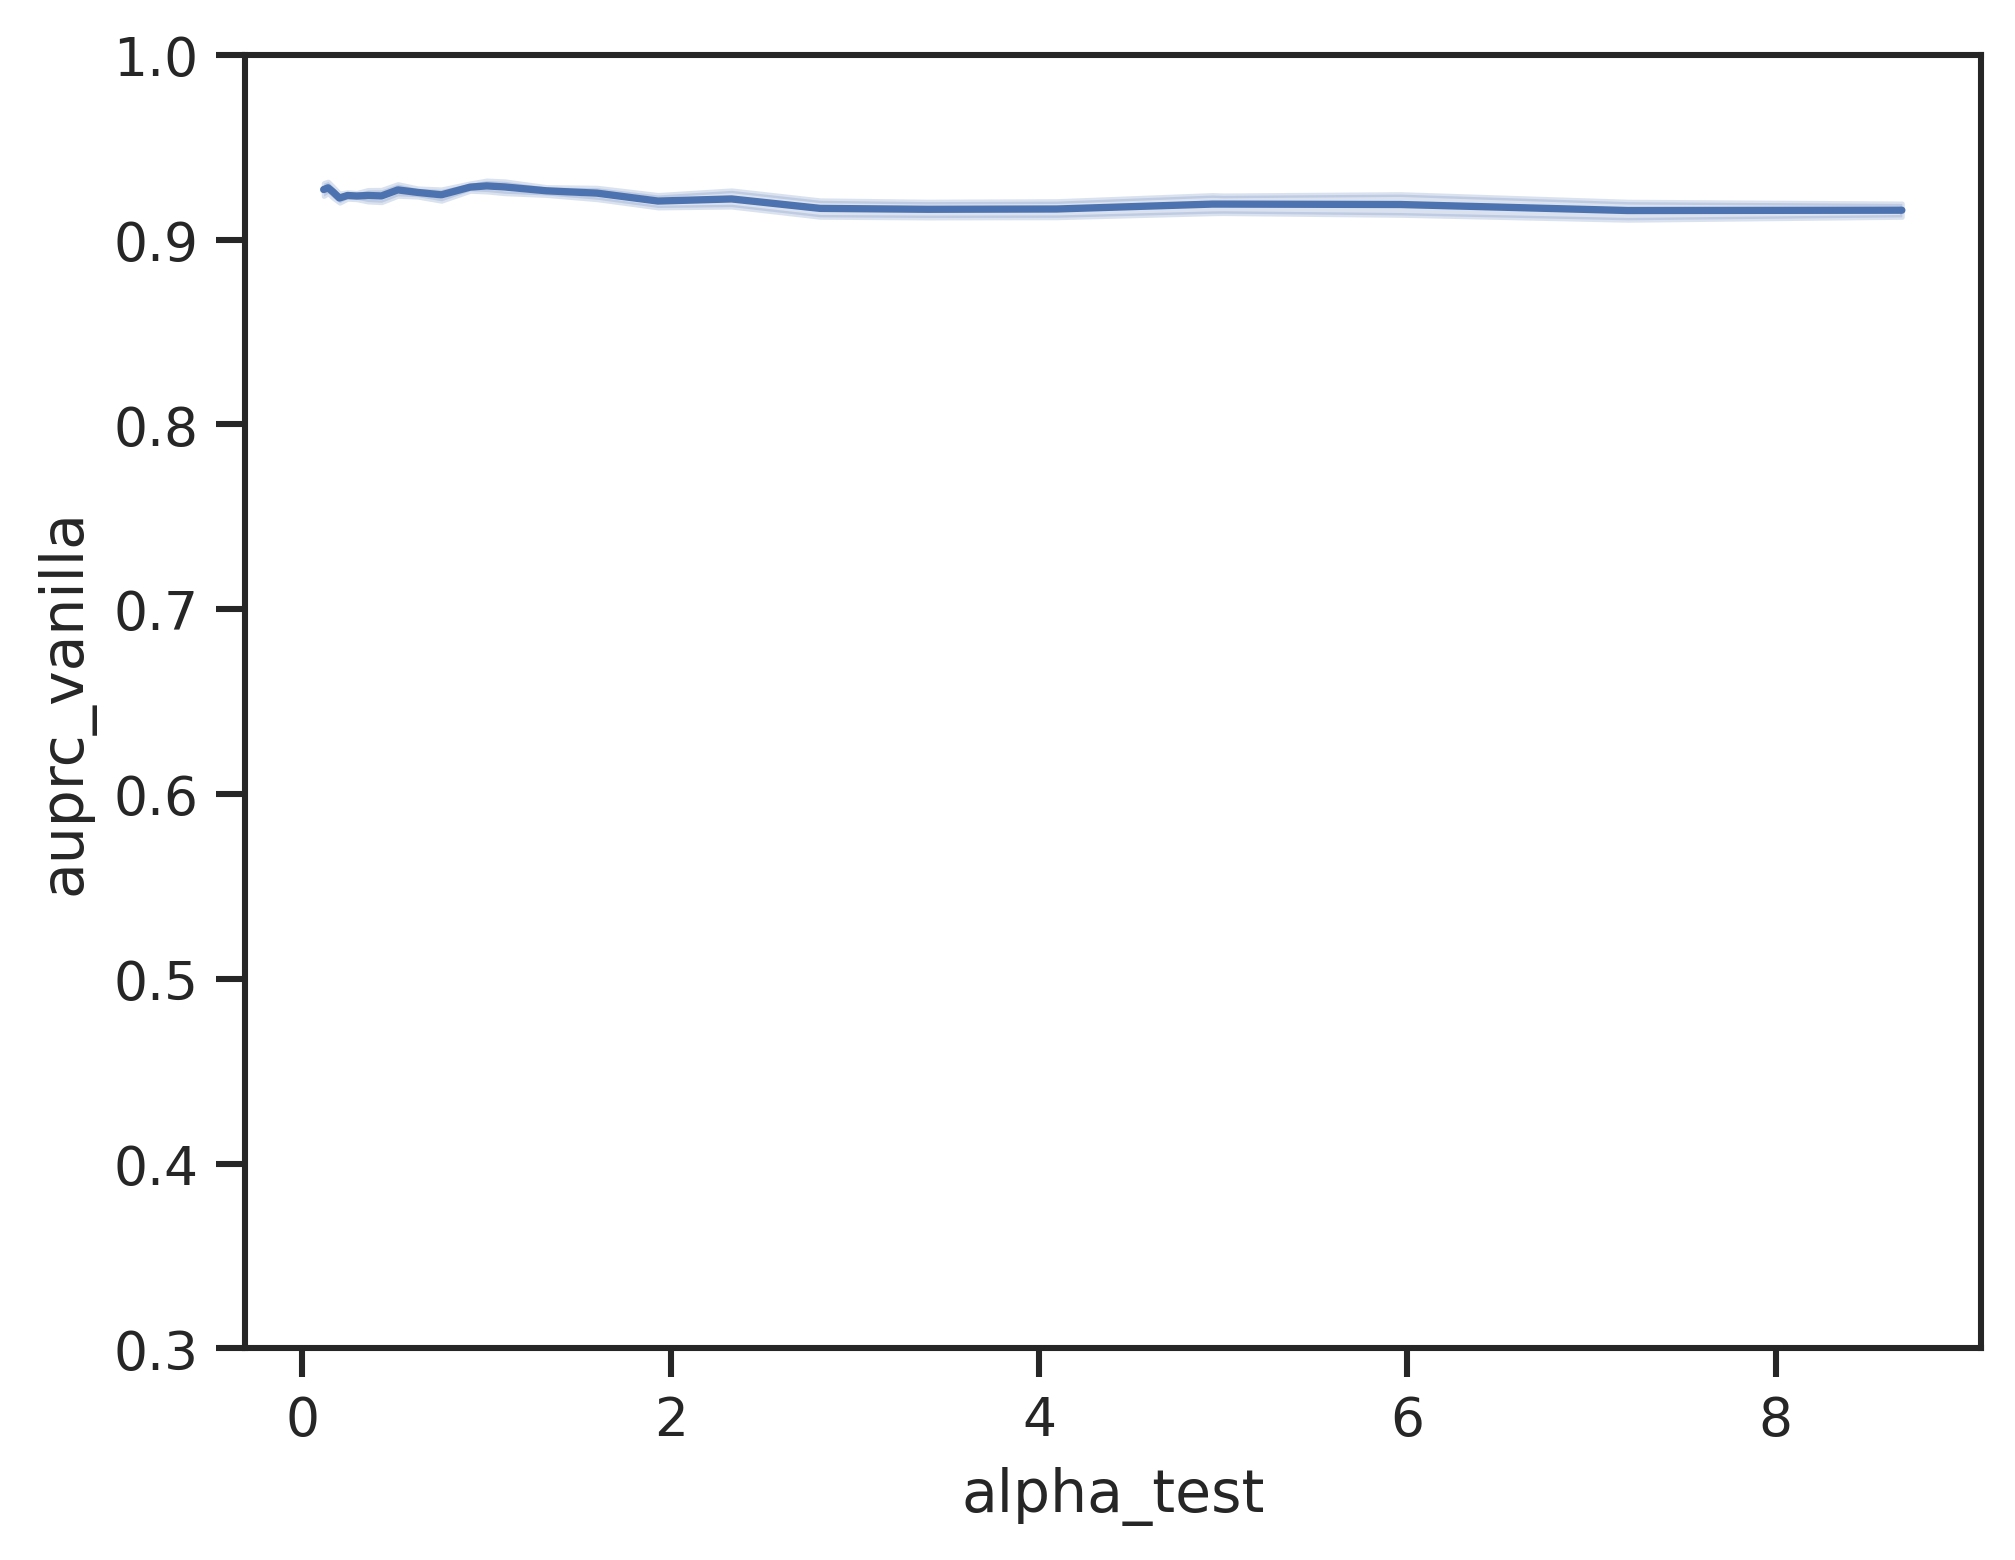

In [67]:
fig, ax = plt.subplots(1,1)

sns.lineplot(_df.query("set == 'mixup_AugUp'").query("alpha_train == 5"), x='alpha_test', y='auprc_vanilla',ax=ax)
# ax.set_xscale('log')
ax.set_ylim(0.3,1)
plt.show()


In [6]:
df_eval['alpha_train'].unique()

array([5. , 1. , 0.2])

In [33]:
pd.reset_option('display.max_rows')

In [8]:
pd.set_option('display.max_rows', None)

In [9]:
df_eval.groupby([ 'C_y', 'alpha_train']).size()

C_y  alpha_train
0.3  0.2            10800
     1.0            10800
     5.0            10800
0.5  0.2            12960
     1.0            12960
     5.0            12960
dtype: int64

In [10]:
df_eval.groupby([ 'C_y', 'C_z', 'alpha_train']).size()

C_y  C_z  alpha_train
0.3  0.5  0.2            10800
          1.0            10800
          5.0            10800
0.5  0.5  0.2            12960
          1.0            12960
          5.0            12960
dtype: int64

In [11]:
df_eval.query("set=='reverseTranslate_AugUp'").groupby([ 'C_y', 'C_z', 'alpha_train']).size()

Series([], dtype: int64)

In [12]:
df_eval.query("set=='mixup_AugUp'").groupby([ 'C_y', 'C_z', 'alpha_train']).size()

C_y  C_z  alpha_train
0.3  0.5  0.2            2700
          1.0            2700
          5.0            2700
0.5  0.5  0.2            3240
          1.0            3240
          5.0            3240
dtype: int64

In [13]:
df_eval.query("set == 'mixup_AugUp'").query("C_y == 0.5").groupby(['alpha_train' , 'C_z']).size()

alpha_train  C_z
0.2          0.5    3240
1.0          0.5    3240
5.0          0.5    3240
dtype: int64

In [14]:
df_eval.query("set == 'mixup_AugUp'").query("C_z == 0.5").groupby(['C_y','alpha_train' , 'C_z']).size()

C_y  alpha_train  C_z
0.3  0.2          0.5    2700
     1.0          0.5    2700
     5.0          0.5    2700
0.5  0.2          0.5    3240
     1.0          0.5    3240
     5.0          0.5    3240
dtype: int64

In [122]:
df_eval.query("set == 'mixup_AugUp'").query("C_z == 0.5").groupby(["C_y_test"]).size()

C_y_test
0.100000    330
0.104927    165
0.116286    165
0.146535    165
0.151795    165
           ... 
0.789440    165
0.800000    165
0.839416    165
0.859634    165
0.900000    165
Length: 103, dtype: int64

In [124]:
df_eval.query("set == 'mixup_AugUp'").query("C_z == 0.5")["C_y_test"].unique()

array([0.10492706, 0.11628557, 0.14653489, 0.16649759, 0.21966109,
       0.25474575, 0.29708567, 0.40984284, 0.48425569, 0.1       ,
       0.3       , 0.15179475, 0.16250552, 0.1754312 , 0.19102982,
       0.20985411, 0.23257114, 0.29306977, 0.33299518, 0.43932218,
       0.50949151, 0.2       , 0.2033472 , 0.21437901, 0.22769212,
       0.24375828, 0.2631468 , 0.31478117, 0.3488567 , 0.38997881,
       0.49949277, 0.5717653 , 0.3       , 0.24884106, 0.25894103,
       0.27112961, 0.30358949, 0.32501104, 0.3508624 , 0.38205964,
       0.41970823, 0.46514227, 0.58613955, 0.4       , 0.5       ,
       0.30058974, 0.31105133, 0.32367629, 0.33891201, 0.35729836,
       0.37948687, 0.4062638 , 0.438578  , 0.47757454, 0.52463529,
       0.58142784, 0.64996468, 0.35030499, 0.36070769, 0.37326159,
       0.38841155, 0.40669441, 0.42875803, 0.45538424, 0.48751656,
       0.5262936 , 0.62956234, 0.69771341, 0.36      , 0.6       ,
       0.39863234, 0.40868915, 0.45314681, 0.47447681, 0.50021

In [ ]:
df_eval.query("C_y==0.5").query("CombinationIdx==566").plot.scatter(x='p_pos_train_z0', y='p_pos_train_z1')
plt.show()

In [36]:
df_eval.query("C_y==0.5").query("alpha_train==0.2").columns

Index(['auprc_backdoor', 'auroc_backdoor', 'precision_backdoor',
       'recall_backdoor', 'f1_backdoor', 'calibration_backdoor',
       'auprc_backdoor_df0', 'auroc_backdoor_df0', 'precision_backdoor_df0',
       'recall_backdoor_df0', 'f1_backdoor_df0', 'calibration_backdoor_df0',
       'auprc_backdoor_df1', 'auroc_backdoor_df1', 'precision_backdoor_df1',
       'recall_backdoor_df1', 'f1_backdoor_df1', 'calibration_backdoor_df1',
       'auprc_vanilla', 'auroc_vanilla', 'precision_vanilla', 'recall_vanilla',
       'f1_vanilla', 'calibration_vanilla', 'auprc_vanilla_df0',
       'auroc_vanilla_df0', 'precision_vanilla_df0', 'recall_vanilla_df0',
       'f1_vanilla_df0', 'calibration_vanilla_df0', 'auprc_vanilla_df1',
       'auroc_vanilla_df1', 'precision_vanilla_df1', 'recall_vanilla_df1',
       'f1_vanilla_df1', 'calibration_vanilla_df1', 'p_pos_train_z0',
       'p_pos_train_z1', 'p_pos_train', 'p_pos_test', 'p_mix_z0', 'p_mix_z1',
       'alpha_train', 'alpha_test', 'p_pos_tes

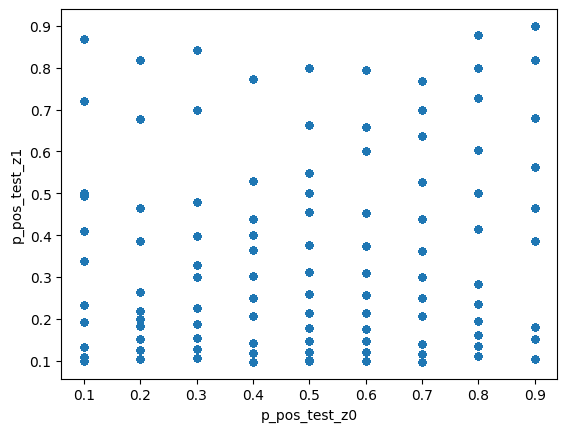

In [31]:
df_eval.query("C_y==0.5").query("alpha_train==0.2").plot.scatter(x='p_pos_test_z0', y='p_pos_test_z1')
plt.show()

In [75]:
set_i = "mixup_AugUp"
alpha_train = 0.25

_df = deepcopy(df_eval)

# _df = _df[_df['dataset'] == dataset].query("C_y.isin([0.5])").query("C_z == 0.5").reset_index(drop=True)
_df = _df[_df['dataset'] == dataset_name].query("C_y.isin([0.5])").reset_index(drop=True)

_df_plt = deepcopy(_df[(_df["alpha_train"] == alpha_train) & (_df["set"] == set_i)])


len(_df_plt)

540

In [76]:
_df_plt

,auprc_backdoor,auroc_backdoor,precision_backdoor,recall_backdoor,f1_backdoor,calibration_backdoor,auprc_backdoor_df0,auroc_backdoor_df0,precision_backdoor_df0,recall_backdoor_df0,...,n_z0_neg_train,n_z0_pos_test,n_z0_neg_test,n_z1_pos_train,n_z1_neg_train,n_z1_pos_test,n_z1_neg_test,run,dataset,set
722,0.329541,0.774142,0.122699,0.952381,0.217391,0.163803,0.216430,0.671111,0.096774,0.900000,...,80,10,90,80,320,11,89,0,HateSpeech,mixup_AugUp
723,0.352119,0.772292,0.137500,0.956522,0.240437,0.220706,0.178151,0.644444,0.097826,0.900000,...,80,10,90,80,320,13,87,0,HateSpeech,mixup_AugUp
724,0.465534,0.813672,0.169697,0.965517,0.288660,0.241134,0.220745,0.688889,0.094737,0.900000,...,80,10,90,80,320,19,81,0,HateSpeech,mixup_AugUp
725,0.474504,0.805480,0.185629,0.939394,0.310000,0.251585,0.193067,0.666667,0.097826,0.900000,...,80,10,90,80,320,23,77,0,HateSpeech,mixup_AugUp
726,0.495537,0.770688,0.264151,0.954545,0.413793,0.333492,0.201612,0.687778,0.102273,0.900000,...,80,10,90,80,320,34,66,0,HateSpeech,mixup_AugUp
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4145,0.868088,0.742009,0.765027,0.958904,0.851064,0.899733,0.932271,0.586667,0.896907,0.966667,...,80,90,10,80,320,56,44,4,HateSpeech,mixup_AugUp
4146,0.905504,0.757233,0.836066,0.968354,0.897361,1.006485,0.926162,0.595556,0.898990,0.988889,...,80,90,10,80,320,68,32,4,HateSpeech,mixup_AugUp
4147,0.944544,0.736711,0.867021,0.947674,0.905556,1.159575,0.937257,0.627778,0.896907,0.966667,...,80,90,10,80,320,82,18,4,HateSpeech,mixup_AugUp
4148,0.801054,0.796498,0.621302,0.972222,0.758123,0.744258,0.939559,0.630000,0.907216,0.977778,...,80,90,10,80,320,18,82,4,HateSpeech,mixup_AugUp


In [78]:
_df['C_z'].unique()

array([0.5, 0.1, 0.2, 0.3, 0.4, 0.6, 0.7, 0.8, 0.9])

In [9]:
df_eval.query("C_y==0.5").groupby(['set', 'alpha_train','C_y','C_z']).size()

set                     alpha_train  C_y  C_z
mixup_AugUp             1.0          0.5  0.1     35
                                          0.2    255
                                          0.3    375
                                          0.4    460
                                          0.5    540
                                          0.6    450
                                          0.7    485
                                          0.8    375
                                          0.9     95
noAug                   1.0          0.5  0.1     35
                                          0.2    255
                                          0.3    375
                                          0.4    460
                                          0.5    540
                                          0.6    450
                                          0.7    485
                                          0.8    375
                                          0.9     95


In [63]:
_df_plt

,auprc_backdoor,auroc_backdoor,precision_backdoor,recall_backdoor,f1_backdoor,calibration_backdoor,auprc_backdoor_df0,auroc_backdoor_df0,precision_backdoor_df0,recall_backdoor_df0,...,n_z0_neg_train,n_z0_pos_test,n_z0_neg_test,n_z1_pos_train,n_z1_neg_train,n_z1_pos_test,n_z1_neg_test,run,dataset,set
722,0.329541,0.774142,0.122699,0.952381,0.217391,0.163803,0.216430,0.671111,0.096774,0.900000,...,80,10,90,80,320,11,89,0,HateSpeech,mixup_AugUp
723,0.352119,0.772292,0.137500,0.956522,0.240437,0.220706,0.178151,0.644444,0.097826,0.900000,...,80,10,90,80,320,13,87,0,HateSpeech,mixup_AugUp
724,0.465534,0.813672,0.169697,0.965517,0.288660,0.241134,0.220745,0.688889,0.094737,0.900000,...,80,10,90,80,320,19,81,0,HateSpeech,mixup_AugUp
725,0.474504,0.805480,0.185629,0.939394,0.310000,0.251585,0.193067,0.666667,0.097826,0.900000,...,80,10,90,80,320,23,77,0,HateSpeech,mixup_AugUp
726,0.495537,0.770688,0.264151,0.954545,0.413793,0.333492,0.201612,0.687778,0.102273,0.900000,...,80,10,90,80,320,34,66,0,HateSpeech,mixup_AugUp
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4145,0.868088,0.742009,0.765027,0.958904,0.851064,0.899733,0.932271,0.586667,0.896907,0.966667,...,80,90,10,80,320,56,44,4,HateSpeech,mixup_AugUp
4146,0.905504,0.757233,0.836066,0.968354,0.897361,1.006485,0.926162,0.595556,0.898990,0.988889,...,80,90,10,80,320,68,32,4,HateSpeech,mixup_AugUp
4147,0.944544,0.736711,0.867021,0.947674,0.905556,1.159575,0.937257,0.627778,0.896907,0.966667,...,80,90,10,80,320,82,18,4,HateSpeech,mixup_AugUp
4148,0.801054,0.796498,0.621302,0.972222,0.758123,0.744258,0.939559,0.630000,0.907216,0.977778,...,80,90,10,80,320,18,82,4,HateSpeech,mixup_AugUp


In [16]:
_df[(_df["alpha_train"] == alpha_train) & (_df["set"] == set_i)]

,auprc_backdoor,auroc_backdoor,precision_backdoor,recall_backdoor,f1_backdoor,calibration_backdoor,auprc_backdoor_df0,auroc_backdoor_df0,precision_backdoor_df0,recall_backdoor_df0,...,n_z0_neg_train,n_z0_pos_test,n_z0_neg_test,n_z1_pos_train,n_z1_neg_train,n_z1_pos_test,n_z1_neg_test,run,dataset,set


# Single Plot for Demo

1215


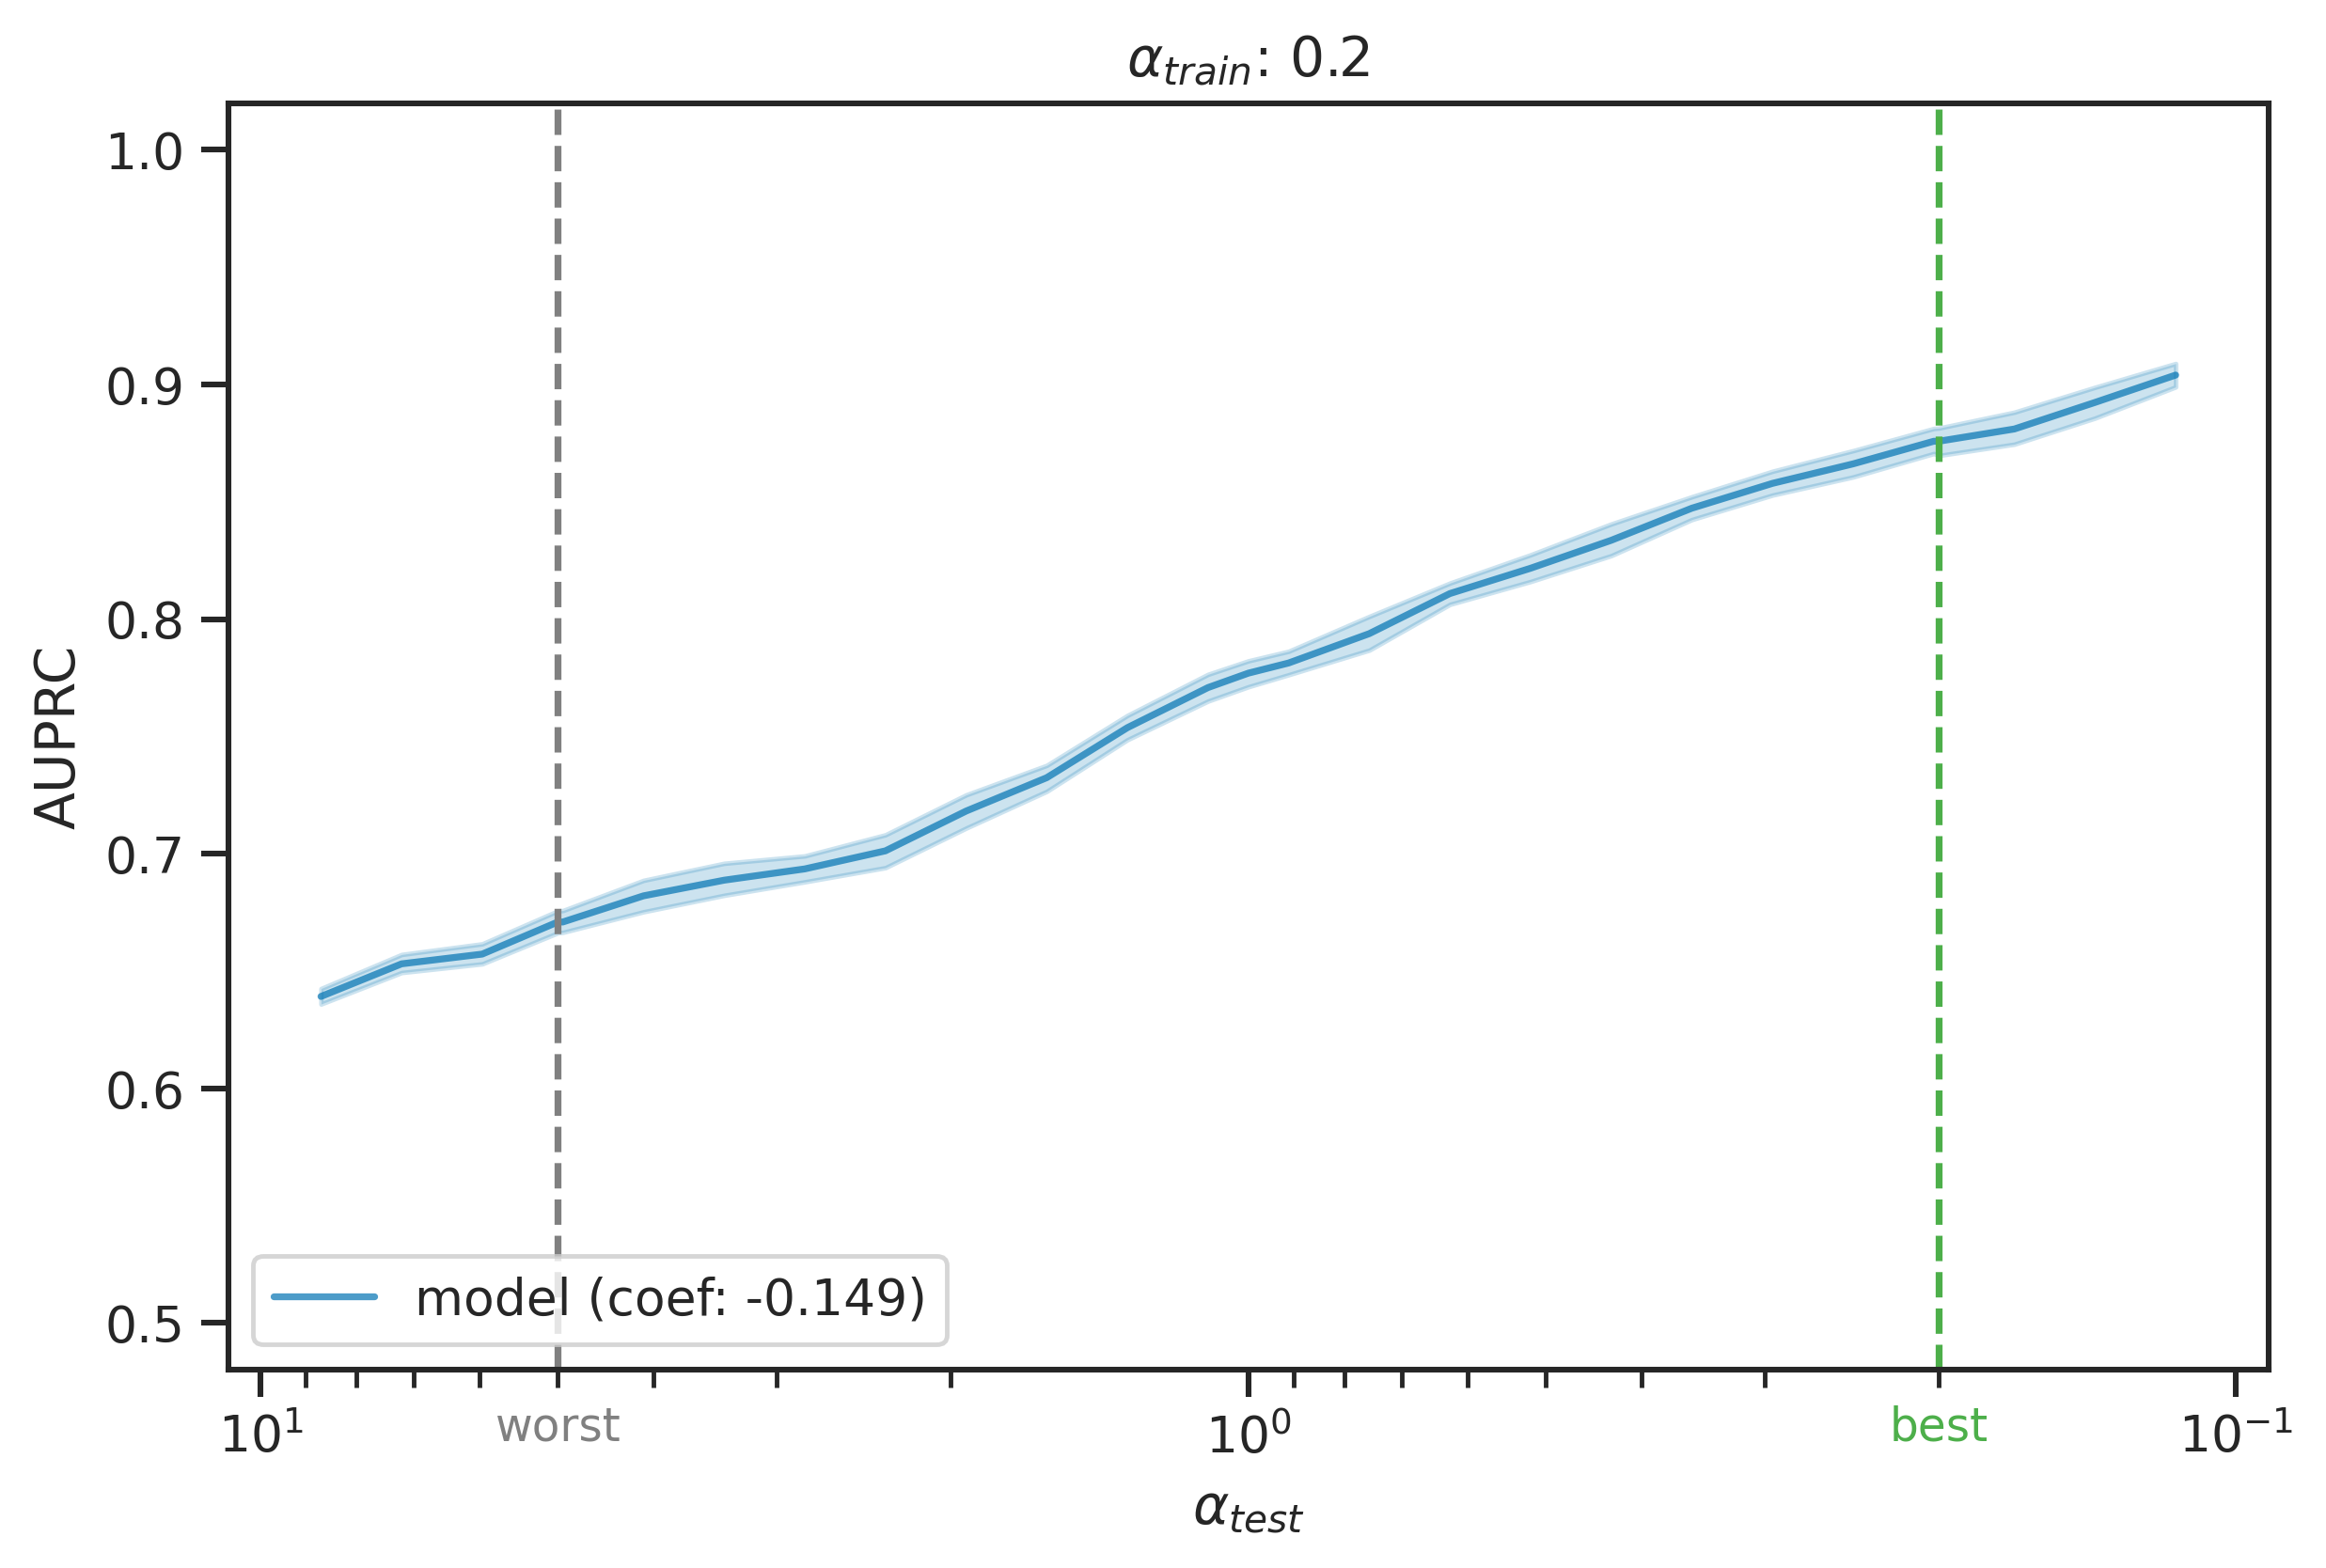

In [90]:
### C_y=0.3, C_z=0.5


# alpha_train_ls = [0.2, 1, 5.0]
# set_ls = ["mixup_AugUp", "resample_AugUp", "noAug"]

# alpha_train_ls = [0.6667, 1, 1.5]
alpha_train_ls = [0.2]

if dataset_name in ['CD']:
    set_ls = ["noAug"]
else:
    set_ls = ["mixup_AugUp", "resample_AugUp", "noAug"]


my_palette = sns.color_palette("colorblind", 5)
my_linestyle = ['solid','dotted']
xticks = [0.1,1,10]

xname = "alpha_test"
# ylabel = "auprc_vanilla"
ylabel = "auprc_backdoor"


outname = f"../output/tmpFig/fig_XXX_{dataset_name}_Cz_0.5_Cy_0.5.png"



if dataset_name == "SHAC":
    y_lower = 0.78
    y_text = 0.75
    y_ref = 0.9
else:
    y_lower = -0.02
    y_text = -0.12
    y_ref = 0.6


_df = deepcopy(df_eval)

_df['C_y_test'] = _df['C_y_test'].round(2)
_df['alpha_train'] = _df['alpha_train'].round(4)

_df = _df[_df['dataset'] == dataset_name].query("C_y_test.isin([0.5])").query("C_z == 0.5").reset_index(drop=True)


fig, axx = plt.subplots(1,1, figsize=(8,5), sharey=True)

ax = [axx]

for i, alpha_train in enumerate(alpha_train_ls):
    
    
    for idx_set, set_i in enumerate(set_ls):
        _df_plt = deepcopy(_df[(_df["alpha_train"] == alpha_train) & (_df["set"] == set_i)])
        # _df_plt = deepcopy(_df[ (_df["set"] == set_i)])

        

        c = my_palette[idx_set]
        lst = 'solid'
        
        print(len(_df_plt))
        reg = get_coefLog10(x=list(_df_plt[xname]), y=list(_df_plt[ylabel]))

        sns.lineplot(data=_df_plt, x=xname, y=ylabel, ax=ax[i], 
                     c=c, 
                     linestyle=lst,
                     alpha=0.7,
                    #  linestyle=my_linestyle[ilambda], label=lambda_com + f" (coef: {reg[0]:.3f})"
                     label="model" + f" (coef: {reg[0]:.3f})"
                    )
        
       
        

    ax[i].set_xscale('log')
                 

    ax[i].axvline(alpha_train, color="#4DAF4A", linestyle='dashed')
    ax[i].axvline(1/alpha_train, color="gray", linestyle='dashed')
    if alpha_train != 1:
        ax[i].text(x=alpha_train, y=0.45, s='best', color="#4DAF4A", fontsize=10, horizontalalignment='center')
        ax[i].text(x=1/alpha_train, y=0.45, s='worst', color="gray", fontsize=10, horizontalalignment='center')

    ax[i].title.set_text(r"$\alpha_{train}$" + f": {alpha_train:.1f}")
    
    ax[i].set_ylim((0.48,1.02))
    # ax[i].set_xticks(xticks)
    ax[i].legend(loc="lower left")
    ax[i].set_xlabel(r"$\alpha_{test}$")
    ax[i].set_ylabel("AUPRC")
    

    
    if alpha_train < 1:
        ax[i].invert_xaxis()
    
    
    

# plt.tight_layout()


plt.show()

plt.close()